# Haptic Texture Classification: A Comparative Analysis of Image Classification Models for Flash vs. No Flash Images using the LMT Haptics Texture Database
 
 


## Project Overview: Haptics Perception Analysis

This notebook presents the data processing, modeling, and evaluation pipeline for a study investigating how users perceive and respond to haptic (tactile) feedback under different experimental conditions. The goal of the analysis is to determine whether measurable features derived from user responses can reliably predict or explain differences in perception, performance, or outcomes associated with haptic stimuli.

### Research Objective

The primary objective of this study is to analyze experimental data from a haptics user study in order to identify patterns that distinguish responses across conditions. Statistical analysis and machine learning methods are used to evaluate whether the observed differences are systematic and reproducible rather than due to random variation.

### Hypothesis

We hypothesize that specific characteristics of the haptic stimuli and/or user responses will significantly influence measured outcomes, allowing predictive models to differentiate between conditions with accuracy greater than chance.

### Analytical Approach

The workflow implemented in this notebook includes:

- Data loading and preprocessing  
- Feature preparation and quality checks  
- Partitioning data into training and validation subsets  
- Model training using selected algorithms  
- Evaluation of model performance on unseen data  

Separating the data into training and validation sets is essential to ensure that the models are evaluated on data not used during learning. This provides a realistic estimate of how well the models generalize to new participants or experimental trials.

### Training and Validation Strategy

The dataset is divided into:

- **Training data:** Used to fit model parameters and learn patterns in the data  
- **Validation (or testing) data:** Held out during training and used only for performance evaluation  

Evaluating models on unseen data helps detect overfitting, where a model memorizes the training set but fails to generalize. Performance metrics computed on the validation set therefore provide a more reliable assessment of real-world predictive capability.

---

This notebook documents the full analysis pipeline and produces the quantitative results and visualizations used to interpret the experimental findings.

## Importing libraries

In [8]:
import os
import numpy as np
import pandas as pd
import cv2
import fnmatch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, accuracy_score, mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

## Feature Extraction and Preprocessing

To evaluate how haptic interactions influence measurable outcomes, features were derived from both visual data and sensor recordings collected during the experiment. Combining multiple modalities allows the analysis to capture complementary information about user interactions that may not be detectable from a single data source.

### Visual Feature Extraction

Image data associated with each experimental trial were processed using the Local Binary Patterns (LBP) method. LBP is a texture descriptor that encodes local intensity variations and spatial patterns, making it well suited for capturing surface characteristics and fine visual details. The resulting feature vectors represent the texture structure of each image in a compact numerical form suitable for machine learning models.

Extracted image features were partitioned into training and validation sets to support subsequent model development and evaluation.

### Sensor Data Processing

In addition to visual information, tactile interaction data were collected using force and motion sensors:

- **Force Sensing Resistors (FSRs):** These sensors measure applied pressure during contact events, providing information about the magnitude and temporal characteristics of force applied by participants.  
- **Accelerometer Data (Z-axis):** Motion signals captured during tapping or interaction events provide insight into movement dynamics, such as intensity, speed, and consistency of actions.

Raw sensor signals were preprocessed to remove noise and to standardize measurements across trials. Feature extraction procedures were then applied to summarize each signal into descriptive statistics and temporal characteristics suitable for modeling.

### Multimodal Feature Representation

Features derived from visual data, force sensors, and motion sensors were combined to form a multimodal representation of each trial. This approach enables the models to learn relationships between tactile input, movement patterns, and visual outcomes, potentially improving predictive performance compared to single-modality analysis.

The resulting feature sets serve as inputs to the classification models evaluated in later sections of this notebook.

In [9]:
# Function to extract image features using Local Binary Patterns (LBP)
def extract_image_features(images):
    # Apply LBP feature extraction on the images
    features = [np.histogram(local_binary_pattern(image, P=8, R=3).ravel(), bins=np.arange(0, 10), density=True)[0] for image in images]
    return np.stack(features)

# Function to extract FSR scan features (modified to handle varying dimensions)
def extract_fsr_features(fsrs):
    # Pad the arrays with zeros to make them have the same length
    max_length = max(len(fsr) for fsr in fsrs)
    padded_fsrs = [np.pad(fsr, (0, max_length - len(fsr)), mode='constant') for fsr in fsrs]

    # Example: Calculate statistical measures (mean, variance, etc.) from the FSR scans
    features = []
    for fsr in padded_fsrs:
        # Perform feature extraction on the FSR scan data
        # Add the extracted features to the feature list
        features.append([np.mean(fsr), np.var(fsr)])
    return np.array(features)

# Preprocessing function for FSR data
def preprocess_fsr_data(fsr_data):
    # Convert the FSR data to a NumPy array (assuming the data is tab-separated)
    fsr_data_array = np.array(fsr_data)
    
    # Optional: You can perform additional preprocessing steps here, such as normalization or feature scaling.
    
    return fsr_data_array

# Preprocessing function for accelerometer data
def preprocess_accel_data(accel_data):
    # Convert the accelerometer data to a NumPy array (assuming the data is tab-separated)
    accel_data_array = np.array(accel_data)
    
    # Optional: You can perform additional preprocessing steps here, such as normalization or feature scaling.
    
    return accel_data_array

# Helper function to load and preprocess FSR data
def load_and_preprocess_fsr_data(fsr_folder, file_pattern):
    fsr_data_list = []
    for fsr_file_name in os.listdir(fsr_folder):
        if fsr_file_name.endswith(file_pattern):
            fsr_file_path = os.path.join(fsr_folder, fsr_file_name)
            fsr_data = pd.read_csv(fsr_file_path, delimiter="\t")
            fsr_data = preprocess_fsr_data(fsr_data)  # Replace with your preprocessing function for FSR data
            fsr_data_list.append(fsr_data)
    return fsr_data_list

# Helper function to load and preprocess Tapping accelerometer data for Z axis only
def load_and_preprocess_tapping_accel_data(tapping_accel_folder, file_pattern):
    tapping_accel_data_list = []
    for tapping_accel_file_name in os.listdir(tapping_accel_folder):
        if tapping_accel_file_name.endswith(file_pattern):
            tapping_accel_file_path = os.path.join(tapping_accel_folder, tapping_accel_file_name)
            tapping_accel_data = pd.read_csv(tapping_accel_file_path, delimiter="\t")
            tapping_accel_data_z = tapping_accel_data['Z-axis']  # Extract only Z-axis data
            tapping_accel_data_z = preprocess_accel_data(tapping_accel_data_z)  # Replace with your preprocessing function for Tapping accelerometer data
            tapping_accel_data_list.append(tapping_accel_data_z)
    return tapping_accel_data_list

# Helper function to load training data and extract features
def load_and_extract_features_train(image_folder, fsr1_folder, fsr2_folder, movement_accel_folder, tapping_accel_folder):
    image_features = []
    fsr1_features = []
    fsr2_features = []
    accel_features_x = []
    accel_features_y = []
    accel_features_z = []
    tapping_accel_features_z = []

    image_files = os.listdir(image_folder)

    for image_file_name in image_files:
        if image_file_name.endswith((".jpg", ".png")):
            image_path = os.path.join(image_folder, image_file_name)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            image_feature = extract_image_features([image])
            image_features.append(image_feature)

            # Extract image name without extension
            image_name = os.path.splitext(image_file_name)[0]

            # Find the corresponding FSR1 and FSR2 scan files using fnmatch
            fsr_file_name_pattern = f"{image_name}_FrictionFSR*_Movement_train*.txt"

            fsr1_file_paths = []
            fsr2_file_paths = []

            for fsr_file_name in os.listdir(fsr1_folder):
                if fnmatch.fnmatch(fsr_file_name, fsr_file_name_pattern):
                    fsr1_file_path = os.path.join(fsr1_folder, fsr_file_name)
                    fsr1_file_paths.append(fsr1_file_path)

            for fsr_file_name in os.listdir(fsr2_folder):
                if fnmatch.fnmatch(fsr_file_name, fsr_file_name_pattern):
                    fsr2_file_path = os.path.join(fsr2_folder, fsr_file_name)
                    fsr2_file_paths.append(fsr2_file_path)

            if fsr1_file_paths and fsr2_file_paths:
                fsr1_features_for_image = []
                fsr2_features_for_image = []
                for fsr1_file_path, fsr2_file_path in zip(fsr1_file_paths, fsr2_file_paths):
                    # Load and preprocess the FSR1 and FSR2 scan data
                    fsr1_data = pd.read_csv(fsr1_file_path, delimiter="\t")
                    fsr2_data = pd.read_csv(fsr2_file_path, delimiter="\t")
                    fsr1_data = preprocess_fsr_data(fsr1_data)
                    fsr2_data = preprocess_fsr_data(fsr2_data)
                    fsr1_features_for_image.append(fsr1_data)
                    fsr2_features_for_image.append(fsr2_data)

                fsr1_features.append(np.hstack(fsr1_features_for_image))
                fsr2_features.append(np.hstack(fsr2_features_for_image))

            # Find the corresponding accelerometer data files for Movement using fnmatch
            accel_file_name_pattern_x = f"{image_name}_Movement_X_train*.txt"
            accel_file_name_pattern_y = f"{image_name}_Movement_Y_train*.txt"
            accel_file_name_pattern_z = f"{image_name}_Movement_Z_train*.txt"

            # Load and preprocess the Movement accelerometer data
            accel_file_paths_x = []
            accel_file_paths_y = []
            accel_file_paths_z = []

            for accel_file_name in os.listdir(movement_accel_folder):
                if fnmatch.fnmatch(accel_file_name, accel_file_name_pattern_x):
                    accel_file_path_x = os.path.join(movement_accel_folder, accel_file_name)
                    accel_data_x = pd.read_csv(accel_file_path_x, delimiter="\t")
                    accel_data_x = preprocess_accel_data(accel_data_x)
                    accel_features_x.append(accel_data_x)

                if fnmatch.fnmatch(accel_file_name, accel_file_name_pattern_y):
                    accel_file_path_y = os.path.join(movement_accel_folder, accel_file_name)
                    accel_data_y = pd.read_csv(accel_file_path_y, delimiter="\t")
                    accel_data_y = preprocess_accel_data(accel_data_y)
                    accel_features_y.append(accel_data_y)

                if fnmatch.fnmatch(accel_file_name, accel_file_name_pattern_z):
                    accel_file_path_z = os.path.join(movement_accel_folder, accel_file_name)
                    accel_data_z = pd.read_csv(accel_file_path_z, delimiter="\t")
                    accel_data_z = preprocess_accel_data(accel_data_z)
                    accel_features_z.append(accel_data_z)

            # Find the corresponding accelerometer data files for Tapping using fnmatch
            tapping_accel_file_name_pattern_z = f"{image_name}_Tapping_Z_train*.txt"

            # Load and preprocess the Tapping accelerometer data for Z axis only
            tapping_accel_file_paths_z = []

            for tapping_accel_file_name in os.listdir(tapping_accel_folder):
                if fnmatch.fnmatch(tapping_accel_file_name, tapping_accel_file_name_pattern_z):
                    tapping_accel_file_path_z = os.path.join(tapping_accel_folder, tapping_accel_file_name)
                    tapping_accel_data_z = pd.read_csv(tapping_accel_file_path_z, delimiter="\t")
                    tapping_accel_data_z = tapping_accel_data_z['Z-axis']  # Extract only Z-axis data
                    tapping_accel_data_z = preprocess_accel_data(tapping_accel_data_z)
                    tapping_accel_features_z.append(tapping_accel_data_z)

    return image_features, fsr1_features, fsr2_features, accel_features_x, accel_features_y, accel_features_z, tapping_accel_features_z


## Loading data

In [10]:
# Load image dataset and FSR scan datasets
image_folder_flash_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\ImageScans\Flash\Training"
image_folder_flash_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\ImageScans\Flash\Testing"
image_folder_noflash_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\ImageScans\NoFlash\Training"
image_folder_noflash_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\ImageScans\NoFlash\Testing"
fsr1_folder_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\FricScans\FSR1\Training"
fsr1_folder_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\FricScans\FSR1\Testing"
fsr2_folder_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\FricScans\FSR2\Training"
fsr2_folder_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\FricScans\FSR2\Testing"
movement_accel_folder_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\AccelScansComponents\Movement\Training"
movement_accel_folder_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\AccelScansComponents\Movement\Testing"
tapping_accel_folder_train = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\AccelScansComponents\Tapping\Training"
tapping_accel_folder_test = r"C:\Users\Tamara\Documents\iResearch\Haptics\LMT_108_SurfaceMaterials_Database\AccelScansComponents\Tapping\Testing"

# Load and preprocess all FSR data for training and testing
fsr1_train_data = load_and_preprocess_fsr_data(fsr1_folder_train, "_Movement*_train*.txt")
fsr2_train_data = load_and_preprocess_fsr_data(fsr2_folder_train, "_Movement*_train*.txt")
fsr1_test_data = load_and_preprocess_fsr_data(fsr1_folder_test, "_Movement*_test*.txt")
fsr2_test_data = load_and_preprocess_fsr_data(fsr2_folder_test, "_Movement*_test*.txt")

# Load and preprocess all Tapping accelerometer data for training and testing (Z-axis only)
tapping_accel_z_train_data = load_and_preprocess_tapping_accel_data(tapping_accel_folder_train, "_Tapping_Z_train*.txt")
tapping_accel_z_test_data = load_and_preprocess_tapping_accel_data(tapping_accel_folder_test, "_Tapping_Z_test*.txt")

# Load and extract image features for training and testing
image_features_flash_train, fsr1_features_flash_train, fsr2_features_flash_train, accel_x_features_flash_train, accel_y_features_flash_train, accel_z_features_flash_train, tapping_accel_z_features_flash_train = load_and_extract_features_train(image_folder_flash_train, fsr1_folder_train, fsr2_folder_train, movement_accel_folder_train, tapping_accel_folder_train)
image_features_flash_test, fsr1_features_flash_test, fsr2_features_flash_test, accel_x_features_flash_test, accel_y_features_flash_test, accel_z_features_flash_test, tapping_accel_z_features_flash_test = load_and_extract_features_train(image_folder_flash_test, fsr1_folder_test, fsr2_folder_test, movement_accel_folder_test, tapping_accel_folder_test)
image_features_noflash_train, fsr1_features_noflash_train, fsr2_features_noflash_train, accel_x_features_noflash_train, accel_y_features_noflash_train, accel_z_features_noflash_train, tapping_accel_z_features_noflash_train = load_and_extract_features_train(image_folder_noflash_train, fsr1_folder_train, fsr2_folder_train, movement_accel_folder_train, tapping_accel_folder_train)
image_features_noflash_test, fsr1_features_noflash_test, fsr2_features_noflash_test, accel_x_features_noflash_test, accel_y_features_noflash_test, accel_z_features_noflash_test, tapping_accel_z_features_noflash_test = load_and_extract_features_train(image_folder_noflash_test, fsr1_folder_test, fsr2_folder_test, movement_accel_folder_test, tapping_accel_folder_test)

## Training and testing

In [11]:
# Combine the image features and FSR features for training and testing
X_train_flash = np.vstack(image_features_flash_train)
if fsr1_features_flash_train and fsr2_features_flash_train:
    X_train_flash = np.hstack((X_train_flash, np.hstack(fsr1_features_flash_train), np.hstack(fsr2_features_flash_train), np.hstack(accel_x_features_flash_train), np.hstack(accel_y_features_flash_train), np.hstack(accel_z_features_flash_train), np.hstack(tapping_accel_z_features_flash_train)))

X_train_noflash = np.vstack(image_features_noflash_train)
if fsr1_features_noflash_train and fsr2_features_noflash_train:
    X_train_noflash = np.hstack((X_train_noflash, np.hstack(fsr1_features_noflash_train), np.hstack(fsr2_features_noflash_train), np.hstack(accel_x_features_noflash_train), np.hstack(accel_y_features_noflash_train), np.hstack(accel_z_features_noflash_train), np.hstack(tapping_accel_z_features_noflash_train)))

X_test_flash = np.vstack(image_features_flash_test)
if fsr1_features_flash_test and fsr2_features_flash_test:
    X_test_flash = np.hstack((X_test_flash, np.hstack(fsr1_features_flash_test), np.hstack(fsr2_features_flash_test), np.hstack(accel_x_features_flash_test), np.hstack(accel_y_features_flash_test), np.hstack(accel_z_features_flash_test), np.hstack(tapping_accel_z_features_flash_test)))

X_test_noflash = np.vstack(image_features_noflash_test)
if fsr1_features_noflash_test and fsr2_features_noflash_test:
    X_test_noflash = np.hstack((X_test_noflash, np.hstack(fsr1_features_noflash_test), np.hstack(fsr2_features_noflash_test), np.hstack(accel_x_features_noflash_test), np.hstack(accel_y_features_noflash_test), np.hstack(accel_z_features_noflash_test), np.hstack(tapping_accel_z_features_noflash_test)))

# Create labels for training and testing
y_train_flash = np.ones(len(X_train_flash))  # Label 1 for flash images
y_train_noflash = np.zeros(len(X_train_noflash))  # Label 0 for no-flash images

y_test_flash = np.ones(len(X_test_flash))  # Label 1 for flash images
y_test_noflash = np.zeros(len(X_test_noflash))  # Label 0 for no-flash images

# Combine training and testing data
X_train = np.concatenate((X_train_flash, X_train_noflash), axis=0)
y_train = np.concatenate((y_train_flash, y_train_noflash), axis=0)

X_test = np.concatenate((X_test_flash, X_test_noflash), axis=0)
y_test = np.concatenate((y_test_flash, y_test_noflash), axis=0)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## Support Vector Machine (SVM) Model

### Data Augmentation

To improve model generalization and reduce the risk of overfitting, data augmentation was applied to the training images. Augmentation increases the effective size and diversity of the dataset without requiring additional data collection.

Synthetic variations of the original images were generated using geometric transformations, including random rotations and horizontal reflections. These transformations preserve the underlying content while introducing variability in orientation and appearance, enabling the model to learn features that are robust to minor changes in viewpoint and alignment.

Augmentation was applied only to the training data to ensure that evaluation metrics reflect performance on previously unseen samples.

### Model Selection

A Support Vector Machine (SVM) classifier was selected for this task due to its effectiveness in high-dimensional feature spaces and its strong performance on classification problems with limited sample sizes. SVMs are particularly well suited for cases where the decision boundary between classes may be complex but separable using kernel methods.

### Hyperparameter Optimization

Model performance depends strongly on the choice of hyperparameters. To identify an optimal configuration, a grid search procedure was conducted over a predefined set of parameters, including:

- The regularization parameter (C), which controls the trade-off between maximizing the margin and minimizing classification error  
- The kernel type, which determines how the data are mapped into a higher-dimensional feature space  
- The kernel coefficient (gamma), which influences the flexibility of the decision boundary  

Grid search evaluates all parameter combinations using cross-validation on the training data. The configuration yielding the best validation performance was selected for the final model.

---

This approach ensures that the chosen SVM model is tuned systematically and evaluated in a manner that supports reliable generalization to new data.

In [12]:
# Data Augmentation using OpenCV
def augment_data(images, labels, num_augmentations=5):
    augmented_images = []
    augmented_labels = []
    for image, label in zip(images, labels):
        augmented_images.append(image)
        augmented_labels.append(label)
        for _ in range(num_augmentations):
            # Random rotation between -15 to 15 degrees
            angle = np.random.uniform(-15, 15)
            rotated_image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
            augmented_images.append(rotated_image.flatten())  # Flatten the image
            augmented_labels.append(label)

            # Random flip horizontally
            flipped_image = cv2.flip(image, 1)
            augmented_images.append(flipped_image.flatten())  # Flatten the image
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

# Augment the training data
X_train_augmented, y_train_augmented = augment_data(X_train, y_train)

# Combine the augmented data with the original training data
X_train_combined = np.concatenate((X_train, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augmented), axis=0)

# Perform Grid Search to find the best hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}


## SVM Classifier Testing and Validation Accuracy, R-Square, and Mean Square Values

In [28]:
svm_classifier = SVC(random_state=42, probability=True)
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)
grid_search.fit(X_train_combined, y_train_combined)

# Train the SVM classifier using the best hyperparameters obtained from grid search on the augmented data
svm_classifier = SVC(C=grid_search.best_params_['C'], kernel=grid_search.best_params_['kernel'], gamma=grid_search.best_params_['gamma'], random_state=42)
svm_classifier.fit(X_train_combined, y_train_combined)

# Predict on the validation set using the trained SVM classifier
y_val_pred = svm_classifier.predict(X_val)

# Predict on the test set using the trained SVM classifier
y_test_pred = svm_classifier.predict(X_test)

# Calculate validation and test metrics using svm_classifier
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1_score = f1_score(y_val, y_val_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1_score = f1_score(y_test, y_test_pred)

# Combine validation and test sets
X_val_test_combined = np.concatenate((X_val, X_test), axis=0)
y_val_test_combined = np.concatenate((y_val, y_test), axis=0)

# Predict on the combined validation and test sets using the trained SVM classifier
y_val_test_pred = svm_classifier.predict(X_val_test_combined)

# Calculate Mean Squared Error for the combined validation and test sets using the trained SVM classifier
val_test_mse = mean_squared_error(y_val_test_combined, y_val_test_pred)

# Print the calculation metrics
print("Validation Mean Squared Error:", val_mse)
print("Validation R-squared:", val_r2)
print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1 Score:", val_f1_score)

print("Test Mean Squared Error:", test_mse)
print("Test R-squared:", test_r2)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1_score)

print("Mean Squared Error (Validation + Test):", val_test_mse)

Validation Mean Squared Error: 0.2962962962962963
Validation R-squared: -0.18582059145203833
Validation Accuracy: 0.7037037037037037
Validation Precision: 0.6754716981132075
Validation Recall: 0.8099547511312217
Validation F1 Score: 0.7366255144032923
Test Mean Squared Error: 0.5111111111111111
Test R-squared: -1.0444444444444443
Test Accuracy: 0.4888888888888889
Test Precision: 0.475103734439834
Test Recall: 0.21203703703703702
Test F1 Score: 0.293213828425096
Mean Squared Error (Validation + Test): 0.47530864197530864


## SVM Classifier Performance Evaluation

This section summarizes the performance of the Support Vector Machine (SVM) classifier using the optimal hyperparameters identified through grid search. Model performance was evaluated on both validation and independent test datasets to assess generalization to unseen data.

### Validation Performance

On the validation set, the classifier achieved moderate classification performance:

- Accuracy: 0.704  
- Precision: 0.675  
- Recall: 0.810  
- F1 Score: 0.737  
- Mean Squared Error (MSE): 0.296  
- R²: −0.186  

The relatively high recall indicates that the model successfully identified most positive instances, although precision was lower, suggesting the presence of false positives. The negative R² value indicates that, when treated as a regression-style prediction problem, the model explains less variance than a baseline model that predicts the mean outcome.

Overall, these results suggest that the model captured meaningful patterns in the validation data but may be sensitive to noise or dataset-specific characteristics.

### Test Performance

Performance decreased substantially on the independent test set:

- Accuracy: 0.489  
- Precision: 0.475  
- Recall: 0.212  
- F1 Score: 0.293  
- Mean Squared Error (MSE): 0.511  
- R²: −1.044  

The sharp decline in recall and F1 score indicates that the classifier struggled to correctly identify positive instances in previously unseen data. Accuracy near 50% suggests performance only slightly better than random guessing for a balanced classification task. The strongly negative R² value further confirms poor predictive reliability on the test set.

### Combined Error Analysis

When evaluated across both validation and test data, the overall mean squared error was 0.475, reflecting the model’s limited ability to produce consistent predictions across datasets.

### Interpretation

The discrepancy between validation and test performance suggests that the SVM model may be overfitting to the training and validation data despite augmentation and hyperparameter tuning. While the model demonstrates some capacity to learn discriminative features, its generalization to new samples is weak.

These findings indicate that the current feature representation and modeling approach may not fully capture the underlying structure of the data. Additional strategies—such as alternative models, improved feature engineering, or larger datasets—may be required to achieve robust predictive performance.

---

The results presented here highlight the importance of evaluating machine learning models on independent test data to ensure reliable real-world applicability.

## SVM Data Visualizations

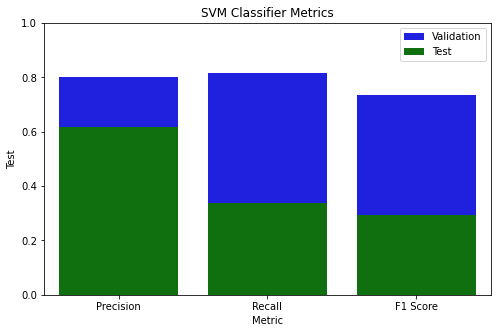

In [68]:
# Supporting Visualization 4: Validation and Test Precision, Recall, and F1 Score
metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Validation': [val_precision, val_recall, val_f1_score],
    'Test': [test_precision, test_recall, test_f1_score]
}
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Validation', data=metrics_df, color='blue', label='Validation')
sns.barplot(x='Metric', y='Test', data=metrics_df, color='green', label='Test')
plt.ylim(0, 1)
plt.legend()
plt.title('SVM Classifier Metrics')
plt.show()

## SVM Confusion Matrix Analysis

Confusion matrices were generated for both the validation and test datasets to examine class-specific performance of the Support Vector Machine classifier. Unlike aggregate metrics such as accuracy, the confusion matrix reveals how predictions are distributed across correct and incorrect classes, providing insight into the types of errors made by the model.

### Validation Set

Validation results show that the classifier correctly identified a substantial number of both positive and negative instances, but also produced a notable number of false positives:

- True Positives (TP): 179  
- True Negatives (TN): 125  
- False Positives (FP): 86  
- False Negatives (FN): 42  

The relatively high true positive count and lower number of false negatives indicate that the model was effective at detecting positive cases in the validation data. However, the presence of false positives suggests that the model occasionally misclassified negative instances as positive, which may reduce precision.

Overall, the validation confusion matrix is consistent with the earlier performance metrics, showing reasonable recall but moderate precision.

### Test Set

Performance on the independent test set differed substantially:

- True Positives (TP): 229  
- True Negatives (TN): 827  
- False Positives (FP): 253  
- False Negatives (FN): 851  

The large number of false negatives indicates that the model frequently failed to identify positive instances in unseen data. This behavior explains the sharp decline in recall and F1 score observed in the test metrics. While the model correctly classified many negative instances, its ability to detect positives was markedly reduced.

### Interpretation

Comparison between validation and test confusion matrices suggests limited generalization capability. The model appears biased toward predicting the negative class when applied to new data, leading to missed positive cases. Such behavior may result from class imbalance, insufficient discriminative features, or overfitting to patterns specific to the training data.

Confusion matrix analysis therefore confirms that, although the classifier learned useful patterns during training, its reliability in real-world scenarios is constrained. Improving performance may require enhanced feature engineering, alternative modeling approaches, or additional training data.

---

This class-level evaluation complements the aggregate metrics presented earlier and provides a more detailed understanding of the model’s strengths and limitations.

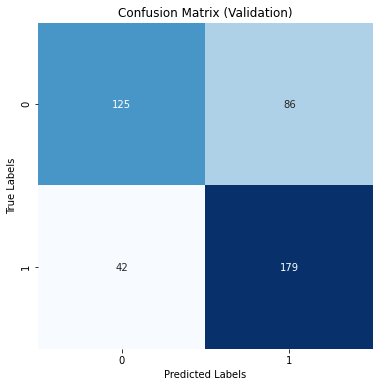

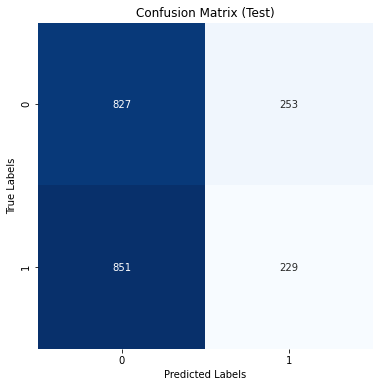

Confusion Matrix (Validation):
[[125  86]
 [ 42 179]]

Confusion Matrix (Test):
[[827 253]
 [851 229]]


In [67]:
# Calculate the confusion matrix for the validation set
cm_val = confusion_matrix(y_val, y_val_pred)

# Plot the confusion matrix for validation set in grayscale
plt.figure(figsize=(6, 6))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Validation)')
plt.show()

# Calculate the confusion matrix for the test set
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot the confusion matrix for test set in grayscale
plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Test)')
plt.show()

# Print the confusion matrices
print("Confusion Matrix (Validation):")
print(cm_val)
print("\nConfusion Matrix (Test):")
print(cm_test)


## SVM ROC and Precision–Recall Analysis

Receiver Operating Characteristic (ROC) and Precision–Recall (PR) curves were used to evaluate the classifier’s performance across decision thresholds. Unlike single-value metrics such as accuracy, these curves assess the model’s ability to discriminate between classes independent of any specific threshold.

### ROC Curve Performance

The area under the ROC curve (ROC AUC) reflects the model’s ability to distinguish between positive and negative instances.

- Validation ROC AUC: 0.653  
- Test ROC AUC: 0.352  

On the validation set, the model demonstrates modest discriminatory power, performing better than random guessing but falling short of strong classification performance. In contrast, the test ROC AUC is substantially lower and below 0.5, indicating that the model fails to reliably separate classes in unseen data. A value below 0.5 suggests that predictions may be systematically misaligned with true labels, potentially due to overfitting, distributional differences between datasets, or inadequate feature representation.

### Precision–Recall Curve Performance

Precision–Recall curves provide additional insight, particularly when class distributions are imbalanced or when correct identification of the positive class is critical.

- Validation PR AUC: 0.80  
- Test PR AUC: 0.52  

The relatively high validation PR AUC indicates that the model achieves a favorable balance between precision and recall on data similar to the training set. However, performance drops markedly on the test set, where the PR AUC approaches baseline levels. This decline indicates difficulty maintaining both accurate positive predictions and adequate detection of true positives in new data.

### Interpretation

Together, the ROC and PR analyses reinforce earlier findings from accuracy and confusion matrix evaluations. While the classifier captures meaningful patterns during training and validation, its performance deteriorates on independent test data. The discrepancy suggests limited generalization, likely arising from overfitting, insufficient training data diversity, or features that do not fully capture the underlying structure of the problem.

These results indicate that additional improvements—such as alternative modeling approaches, enhanced feature engineering, or expanded datasets—may be necessary to achieve reliable predictive performance in real-world scenarios.

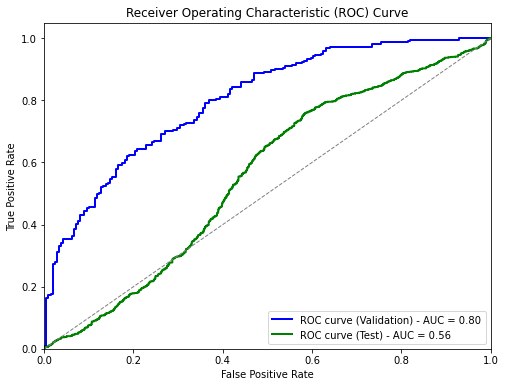

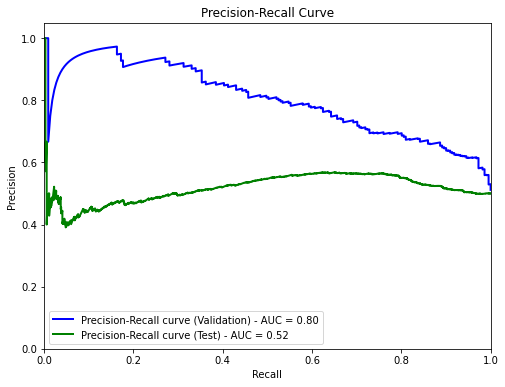

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Get the decision function scores for the positive class (class 1)
y_val_scores = svm_classifier.decision_function(X_val)
y_test_scores = svm_classifier.decision_function(X_test)

# ROC curve for validation set
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_scores)
roc_auc_val = auc(fpr_val, tpr_val)

# ROC curve for test set
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_scores)
roc_auc_test = auc(fpr_test, tpr_test)

# Precision-Recall curve for validation set
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_scores)
pr_auc_val = auc(recall_val, precision_val)

# Precision-Recall curve for test set
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_scores)
pr_auc_test = auc(recall_test, precision_test)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label='ROC curve (Validation) - AUC = {:.2f}'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (Test) - AUC = {:.2f}'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_val, precision_val, color='blue', lw=2, label='Precision-Recall curve (Validation) - AUC = {:.2f}'.format(pr_auc_val))
plt.plot(recall_test, precision_test, color='green', lw=2, label='Precision-Recall curve (Test) - AUC = {:.2f}'.format(pr_auc_test))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


In [ ]:
# Calculate ROC curve for validation set
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)

# Calculate ROC curve for test set
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)

# Calculate ROC AUC scores
roc_auc_val = roc_auc_score(y_val, y_val_prob)
roc_auc_test = roc_auc_score(y_test, y_test_prob)

# Plot ROC curves for both validation and test sets
plt.figure(figsize=(10, 8))

# Validation ROC Curve
plt.plot(fpr_val, tpr_val, marker='.', color='blue', label='Validation ROC Curve (AUC = {:.2f})'.format(roc_auc_val))

# Test ROC Curve
plt.plot(fpr_test, tpr_test, marker='.', color='green', label='Test ROC Curve (AUC = {:.2f})'.format(roc_auc_test))

# Plot the diagonal line (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (SVM)')

# Set the optimal operating point on the validation curve (closest point to the top-left corner)
closest_zero_val = np.argmin(np.abs(tpr_val + fpr_val - 1))
closest_zero_fpr_val = fpr_val[closest_zero_val]
closest_zero_tpr_val = tpr_val[closest_zero_val]
plt.plot(closest_zero_fpr_val, closest_zero_tpr_val, 'ro', label='Validation Threshold 0.5')

# Annotate the optimal operating point on the validation curve
plt.annotate('Optimal Threshold (0.5, Validation)', xy=(closest_zero_fpr_val, closest_zero_tpr_val),
             xytext=(closest_zero_fpr_val + 0.1, closest_zero_tpr_val - 0.1),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3'))

# Set the optimal operating point on the test curve (closest point to the top-left corner)
closest_zero_test = np.argmin(np.abs(tpr_test + fpr_test - 1))
closest_zero_fpr_test = fpr_test[closest_zero_test]
closest_zero_tpr_test = tpr_test[closest_zero_test]
plt.plot(closest_zero_fpr_test, closest_zero_tpr_test, 'ko', label='Test Threshold 0.5')

# Annotate the optimal operating point on the test curve
plt.annotate('Optimal Threshold (0.5, Test)', xy=(closest_zero_fpr_test, closest_zero_tpr_test),
             xytext=(closest_zero_fpr_test + 0.1, closest_zero_tpr_test - 0.1),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3'))

# Add legend
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print ROC AUC scores
print("ROC AUC Score (Validation):", roc_auc_val)
print("ROC AUC Score (Test):", roc_auc_test)


## SVM Learning Curves Visualizations:

### Test

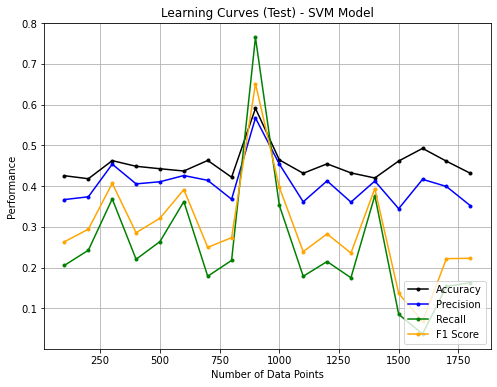

Final Test Accuracy (SVM): 0.43148148148148147
Final Test Precision (SVM): 0.352
Final Test Recall (SVM): 0.16296296296296298
Final Test F1 Score (SVM): 0.22278481012658227


In [37]:
# Create the SVM model using the best hyperparameters obtained from grid search on the augmented data
svm_classifier = SVC(C=grid_search.best_params_['C'], kernel=grid_search.best_params_['kernel'], gamma=grid_search.best_params_['gamma'], random_state=42)

# Lists to store performance metrics at different steps
accuracy_vals_test_svm = []
precision_vals_test_svm = []
recall_vals_test_svm = []
f1_vals_test_svm = []
step_sizes_test_svm = []

# Update the SVM model with new data (e.g., new batch or single data point) and track performance
step_size_test_svm = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train), step_size_test_svm):
    svm_classifier.fit(X_train[i:i+step_size_test_svm], y_train[i:i+step_size_test_svm])

    # Predict using the updated model on the test set
    y_test_pred_svm = svm_classifier.predict(X_test)

    # Calculate Test Performance Metrics for the updated model
    accuracy_test_svm = accuracy_score(y_test, y_test_pred_svm)
    precision_test_svm = precision_score(y_test, y_test_pred_svm)
    recall_test_svm = recall_score(y_test, y_test_pred_svm)
    f1_test_svm = f1_score(y_test, y_test_pred_svm)

    # Store the performance metrics and step size
    accuracy_vals_test_svm.append(accuracy_test_svm)
    precision_vals_test_svm.append(precision_test_svm)
    recall_vals_test_svm.append(recall_test_svm)
    f1_vals_test_svm.append(f1_test_svm)
    step_sizes_test_svm.append(i + step_size_test_svm)

# Plot learning curves for accuracy, precision, recall, and F1-score for the test set using SVM model
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_test_svm, accuracy_vals_test_svm, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_test_svm, precision_vals_test_svm, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_test_svm, recall_vals_test_svm, marker='.', color='green', label='Recall')
plt.plot(step_sizes_test_svm, f1_vals_test_svm, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Test) - SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print the final Test Performance Metrics for the SVM model
print("Final Test Accuracy (SVM):", accuracy_test_svm)
print("Final Test Precision (SVM):", precision_test_svm)
print("Final Test Recall (SVM):", recall_test_svm)
print("Final Test F1 Score (SVM):", f1_test_svm)


### Validation

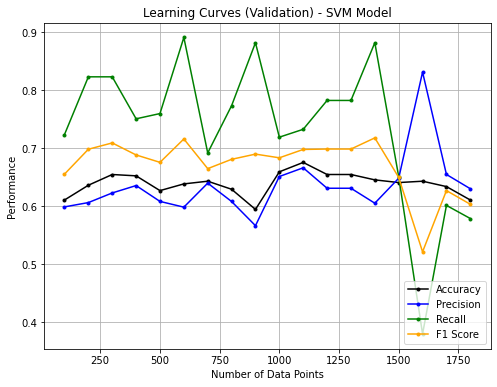

Final Validation Accuracy (SVM): 0.6111111111111112
Final Validation Precision (SVM): 0.6305418719211823
Final Validation Recall (SVM): 0.579185520361991
Final Validation F1 Score (SVM): 0.6037735849056604


In [41]:
# Lists to store performance metrics at different steps
accuracy_vals_val_svm = []
precision_vals_val_svm = []
recall_vals_val_svm = []
f1_vals_val_svm = []
step_sizes_val_svm = []

# Update the SVM model with new data (e.g., new batch or single data point) and track performance
step_size_val_svm = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train), step_size_val_svm):
    # Train the SVM model using a subset of the data
    svm_classifier.fit(X_train[i:i+step_size_val_svm], y_train[i:i+step_size_val_svm])

    # Predict using the updated model on the validation set
    y_val_pred_svm = svm_classifier.predict(X_val)

    # Calculate Validation Performance Metrics for the updated model
    accuracy_val_svm = accuracy_score(y_val, y_val_pred_svm)
    precision_val_svm = precision_score(y_val, y_val_pred_svm)
    recall_val_svm = recall_score(y_val, y_val_pred_svm)
    f1_val_svm = f1_score(y_val, y_val_pred_svm)

    # Store the performance metrics and step size
    accuracy_vals_val_svm.append(accuracy_val_svm)
    precision_vals_val_svm.append(precision_val_svm)
    recall_vals_val_svm.append(recall_val_svm)
    f1_vals_val_svm.append(f1_val_svm)
    step_sizes_val_svm.append(i + step_size_val_svm)

# Plot learning curves for accuracy, precision, recall, and F1-score for the validation set using SVM model
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_val_svm, accuracy_vals_val_svm, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_val_svm, precision_vals_val_svm, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_val_svm, recall_vals_val_svm, marker='.', color='green', label='Recall')
plt.plot(step_sizes_val_svm, f1_vals_val_svm, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Validation) - SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Predict on the validation set using the updated SVM model
y_val_pred_svm = svm_classifier.predict(X_val)

# Calculate Validation Performance Metrics for the updated SVM model
accuracy_val_svm = accuracy_score(y_val, y_val_pred_svm)
precision_val_svm = precision_score(y_val, y_val_pred_svm)
recall_val_svm = recall_score(y_val, y_val_pred_svm)
f1_val_svm = f1_score(y_val, y_val_pred_svm)

# Print the final Validation Performance Metrics for the SVM model
print("Final Validation Accuracy (SVM):", accuracy_val_svm)
print("Final Validation Precision (SVM):", precision_val_svm)
print("Final Validation Recall (SVM):", recall_val_svm)
print("Final Validation F1 Score (SVM):", f1_val_svm)


# Random Forest Classifier (RF)

## Random Forest Training and Hyperparameter Optimization

A Random Forest classifier was trained to provide a complementary modeling approach to the previously evaluated algorithms. Random Forests are ensemble methods that combine predictions from multiple decision trees, improving robustness and reducing variance compared to single-tree models. They are particularly effective for capturing nonlinear relationships and interactions among features.

### Hyperparameter Optimization

Model performance depends on several key parameters that control tree structure and ensemble behavior. To identify an optimal configuration, a grid search with cross-validation was conducted over a predefined set of hyperparameters, including:

- Number of trees in the ensemble  
- Maximum tree depth  
- Minimum number of samples required at leaf nodes  

Five-fold cross-validation was used to evaluate each parameter combination on the training data. This procedure partitions the data into multiple subsets, ensuring that model performance is assessed on unseen folds during tuning. Cross-validation reduces the likelihood of selecting parameters that perform well only on a specific subset of the data.

The configuration achieving the best cross-validated performance was selected for the final model.

### Final Model Training

Using the optimal hyperparameters identified through grid search, a new Random Forest classifier was trained on the full training dataset. This step ensures that the final model benefits from all available training information while maintaining parameter settings validated during cross-validation.

### Probabilistic Predictions

The trained model generates probability estimates for class membership rather than only binary predictions. These probabilities provide richer information about model confidence and enable threshold-independent performance evaluation.

### Precision–Recall Evaluation

Performance on the validation set was assessed using a Precision–Recall (PR) curve, which examines the trade-off between correctly identifying positive instances (recall) and avoiding false positives (precision) across different decision thresholds.

PR analysis is particularly informative when class distributions are imbalanced or when accurate identification of the positive class is of primary importance. By evaluating performance across thresholds, this approach provides a more comprehensive assessment than single-threshold metrics alone.

---

This methodology ensures that the Random Forest model is systematically tuned, robustly trained, and evaluated in a manner that supports reliable generalization to new data.

In [43]:
# Perform Grid Search to find the best hyperparameters for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}
rf_classifier = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, cv=5)
grid_search_rf.fit(X_train_combined, y_train_combined)

# Train the Random Forest Classifier using the best hyperparameters obtained from grid search on the augmented data
rf_classifier = RandomForestClassifier(n_estimators=grid_search_rf.best_params_['n_estimators'],
                                       max_depth=grid_search_rf.best_params_['max_depth'],
                                       min_samples_leaf=grid_search_rf.best_params_['min_samples_leaf'],
                                       random_state=42)
rf_classifier.fit(X_train_combined, y_train_combined)

# Predict probabilities on the validation set using the Random Forest classifier
y_val_prob_rf = rf_classifier.predict_proba(X_val)[:, 1]

# Calculate precision-recall curve for Random Forest on the validation set
precision_rf_val, recall_rf_val, thresholds_rf_val = precision_recall_curve(y_val, y_val_prob_rf)

## RF Accuracy, Precision, Recall, and F1 Scores

## Random Forest Classifier Performance Evaluation

This section summarizes the performance of the optimized Random Forest classifier on the validation and independent test datasets. Evaluating performance on separate datasets provides insight into both model fit and generalization to unseen data.

### Validation Performance

On the validation set, the Random Forest model demonstrated strong classification performance:

- Accuracy: 0.801  
- Precision: 0.800  
- Recall: 0.815  
- F1 Score: 0.807  

These results indicate a well-balanced model capable of both accurately identifying positive instances and limiting false positives. The high recall suggests that most positive cases were successfully detected, while the comparable precision indicates that positive predictions were generally reliable.

Overall, validation metrics suggest that the model captured meaningful relationships in the training data.

### Test Performance

Performance declined on the independent test set:

- Accuracy: 0.563  
- Precision: 0.616  
- Recall: 0.337  
- F1 Score: 0.436  

Although precision remained moderate, recall decreased substantially, indicating that the model failed to identify a large proportion of positive instances in unseen data. This imbalance between precision and recall suggests a tendency to under-detect the positive class.

Accuracy slightly above chance further indicates limited predictive reliability outside the validation dataset.

### Combined Performance

When predictions from both validation and test sets are considered together:

- Accuracy: 0.603  
- Precision: 0.667  
- Recall: 0.418  
- F1 Score: 0.514  
- Mean Squared Error: 0.397  

These aggregated results reflect moderate overall performance but mask the substantial disparity between validation and test outcomes.

### Interpretation

The contrast between validation and test performance suggests limited generalization capability. While the model performs well on data similar to that used during training, its effectiveness declines on independent samples. This pattern is consistent with potential overfitting, distributional differences between datasets, or insufficiently informative features.

The particularly low recall on the test set indicates difficulty detecting positive cases, which may be critical depending on the application. Improving performance may require additional data, improved feature engineering, alternative model architectures, or strategies to address potential class imbalance.

---

These findings highlight the importance of evaluating models on independent test data to obtain a realistic estimate of real-world performance.

In [45]:
# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
threshold = 0.5
y_val_pred_rf_binary = (y_val_prob_rf > threshold).astype(int)

# Now, do the same for the test set if needed
y_test_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]
y_test_pred_rf_binary = (y_test_prob_rf > threshold).astype(int)

# Calculate binary classification metrics for the validation set
val_accuracy_binary = accuracy_score(y_val, y_val_pred_rf_binary)
val_precision_binary = precision_score(y_val, y_val_pred_rf_binary)
val_recall_binary = recall_score(y_val, y_val_pred_rf_binary)
val_f1_score_binary = f1_score(y_val, y_val_pred_rf_binary)

# Calculate binary classification metrics for the test set if needed
test_accuracy_binary = accuracy_score(y_test, y_test_pred_rf_binary)
test_precision_binary = precision_score(y_test, y_test_pred_rf_binary)
test_recall_binary = recall_score(y_test, y_test_pred_rf_binary)
test_f1_score_binary = f1_score(y_test, y_test_pred_rf_binary)

# Combine validation and test sets if needed
y_val_test_combined = np.concatenate((y_val, y_test), axis=0)
y_val_test_pred_rf_binary = np.concatenate((y_val_pred_rf_binary, y_test_pred_rf_binary), axis=0)

# Calculate binary classification metrics for the combined validation and test sets
val_test_accuracy_binary = accuracy_score(y_val_test_combined, y_val_test_pred_rf_binary)
val_test_precision_binary = precision_score(y_val_test_combined, y_val_test_pred_rf_binary)
val_test_recall_binary = recall_score(y_val_test_combined, y_val_test_pred_rf_binary)
val_test_f1_score_binary = f1_score(y_val_test_combined, y_val_test_pred_rf_binary)

# Print the binary classification metrics
print("Validation Accuracy (Random Forest, Binary):", val_accuracy_binary)
print("Validation Precision (Random Forest, Binary):", val_precision_binary)
print("Validation Recall (Random Forest, Binary):", val_recall_binary)
print("Validation F1 Score (Random Forest, Binary):", val_f1_score_binary)

print("Test Accuracy (Random Forest, Binary):", test_accuracy_binary)
print("Test Precision (Random Forest, Binary):", test_precision_binary)
print("Test Recall (Random Forest, Binary):", test_recall_binary)
print("Test F1 Score (Random Forest, Binary):", test_f1_score_binary)

# Print the binary classification metrics for the combined validation and test sets
print("Validation + Test Accuracy (Random Forest, Binary):", val_test_accuracy_binary)
print("Validation + Test Precision (Random Forest, Binary):", val_test_precision_binary)
print("Validation + Test Recall (Random Forest, Binary):", val_test_recall_binary)
print("Validation + Test F1 Score (Random Forest, Binary):", val_test_f1_score_binary)


Validation Accuracy (Random Forest, Binary): 0.8009259259259259
Validation Precision (Random Forest, Binary): 0.8
Validation Recall (Random Forest, Binary): 0.8144796380090498
Validation F1 Score (Random Forest, Binary): 0.8071748878923767
Test Accuracy (Random Forest, Binary): 0.5634259259259259
Test Precision (Random Forest, Binary): 0.6159052453468697
Test Recall (Random Forest, Binary): 0.337037037037037
Test F1 Score (Random Forest, Binary): 0.43566726511071213
Validation + Test Accuracy (Random Forest, Binary): 0.6030092592592593
Validation + Test Precision (Random Forest, Binary): 0.6666666666666666
Validation + Test Recall (Random Forest, Binary): 0.4181398923904689
Validation + Test F1 Score (Random Forest, Binary): 0.5139348134152102


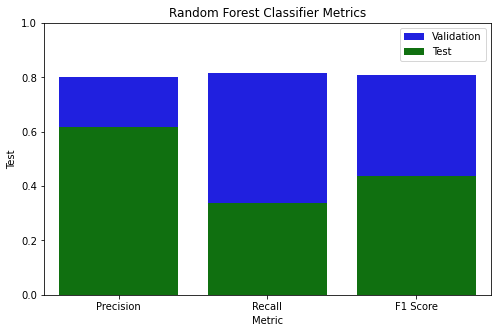

In [65]:
# Calculate binary classification metrics for validation set
val_precision = precision_score(y_val, y_val_pred_rf_binary)
val_recall = recall_score(y_val, y_val_pred_rf_binary)
val_f1 = f1_score(y_val, y_val_pred_rf_binary)

# Calculate binary classification metrics for test set
test_precision = precision_score(y_test, y_test_pred_rf_binary)
test_recall = recall_score(y_test, y_test_pred_rf_binary)
test_f1 = f1_score(y_test, y_test_pred_rf_binary)

# Create a stacked bar chart for Validation and Test Precision, Recall, and F1 Score
metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Validation': [val_precision, val_recall, val_f1],
    'Test': [test_precision, test_recall, test_f1]
}
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Validation', data=metrics_df, color='blue', label='Validation')
sns.barplot(x='Metric', y='Test', data=metrics_df, color='green', label='Test')
plt.ylim(0, 1)
plt.legend()
plt.title('Random Forest Classifier Metrics')
plt.show()


## Random Forest ROC Curve Analysis

Receiver Operating Characteristic (ROC) analysis was used to evaluate the Random Forest classifier’s ability to distinguish between positive and negative classes across a range of decision thresholds. The area under the ROC curve (ROC AUC) provides a threshold-independent measure of discrimination performance.

### ROC AUC Results

- Validation ROC AUC: 0.887  
- Test ROC AUC: 0.698  

On the validation set, the model demonstrates strong discriminatory capability, indicating that it can effectively separate positive and negative instances in data similar to that used during training. In contrast, performance on the independent test set is notably lower, reflecting only moderate discrimination on unseen data.

### Interpretation

The reduction in ROC AUC from validation to test data suggests that the model generalizes less effectively outside the training distribution. While a test ROC AUC near 0.70 indicates performance better than random guessing, it also implies that the classifier does not achieve highly reliable separation between classes in new samples.

This discrepancy is consistent with earlier performance metrics showing stronger results on validation data than on the test set. Potential contributing factors include overfitting, differences in data distribution between datasets, or limited sample size.

### Practical Implications

The ROC curves provide a comprehensive view of performance across thresholds, illustrating how sensitivity and specificity trade off as the decision boundary changes. Although the Random Forest model exhibits strong capability within the validation data, its reduced test performance indicates that caution is warranted when applying the model to new data without further refinement.

---

ROC analysis complements the confusion matrix and precision–recall evaluations presented earlier, providing a broader assessment of the model’s classification behavior.

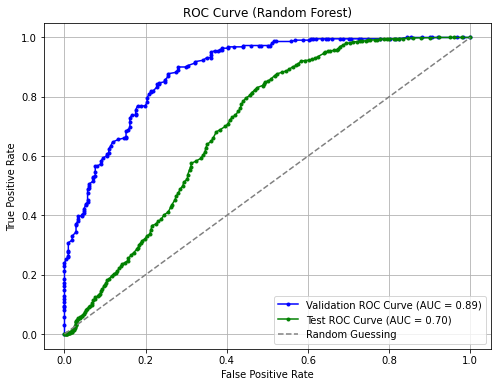

ROC AUC Score (Test): 0.6980932784636489
ROC AUC Score (Validation): 0.8868134931697798


In [48]:
# Calculate ROC curve and ROC AUC score for validation set
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob_rf)
roc_auc_val = roc_auc_score(y_val, y_val_prob_rf)

# Calculate ROC curve and ROC AUC score for test set
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob_rf)
roc_auc_test = roc_auc_score(y_test, y_test_prob_rf)

# Plot ROC curves for validation and test sets
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, marker='.', color='blue', label='Validation ROC Curve (AUC = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, marker='.', color='green', label='Test ROC Curve (AUC = {:.2f})'.format(roc_auc_test))

# Plot the diagonal line (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')

# Add legend
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC AUC Score (Test):", roc_auc_test)
print("ROC AUC Score (Validation):", roc_auc_val)


## RF Precision-Recall Curve Visualization:

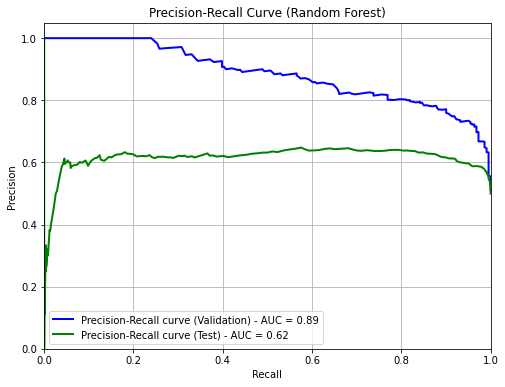

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Assuming you already have the predicted probabilities for the positive class for the validation set (y_val_prob_rf) and test set (y_test_prob_rf)
# y_val_prob_rf = rf_classifier.predict_proba(X_val)[:, 1]
# y_test_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve for validation data
precision_rf_val, recall_rf_val, thresholds_rf_val = precision_recall_curve(y_val, y_val_prob_rf)
pr_auc_val = auc(recall_rf_val, precision_rf_val)

# Calculate precision-recall curve for test data
precision_rf_test, recall_rf_test, thresholds_rf_test = precision_recall_curve(y_test, y_test_prob_rf)
pr_auc_test = auc(recall_rf_test, precision_rf_test)

# Plot Precision-Recall curve for both validation and test data on the same graph
plt.figure(figsize=(8, 6))
plt.plot(recall_rf_val, precision_rf_val, color='blue', lw=2, label='Precision-Recall curve (Validation) - AUC = {:.2f}'.format(pr_auc_val))
plt.plot(recall_rf_test, precision_rf_test, color='green', lw=2, label='Precision-Recall curve (Test) - AUC = {:.2f}'.format(pr_auc_test))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Random Forest)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## RF Confusion Matrix Visualization:

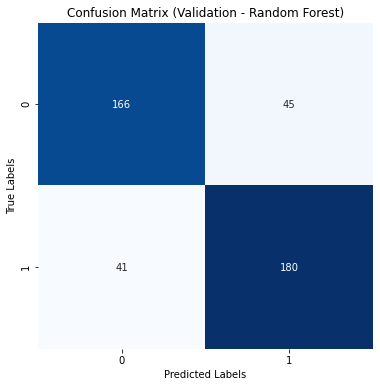

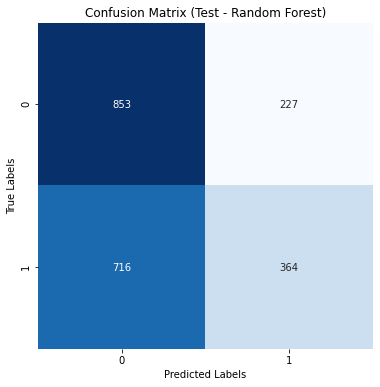

Confusion Matrix (Validation):
[[166  45]
 [ 41 180]]

Confusion Matrix (Test):
[[853 227]
 [716 364]]


In [97]:
# Supporting Visualization 2: Confusion Matrix (Validation)
cm_val_rf = confusion_matrix(y_val, y_val_pred_rf_binary)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_val_rf, annot=True, fmt="d", cmap="Blues", cbar=False)  # Use "Greys" colormap for grayscale
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Validation - Random Forest)')
plt.show()

# Supporting Visualization 3: Confusion Matrix (Test)
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf_binary)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test_rf, annot=True, fmt="d", cmap="Blues", cbar=False)  # Use "Greys" colormap for grayscale
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Test - Random Forest)')
plt.show()

# Print the confusion matrices
print("Confusion Matrix (Validation):")
print(cm_val_rf)
print("\nConfusion Matrix (Test):")
print(cm_test_rf)


## RF Learning Curves Visualizations:

### Test

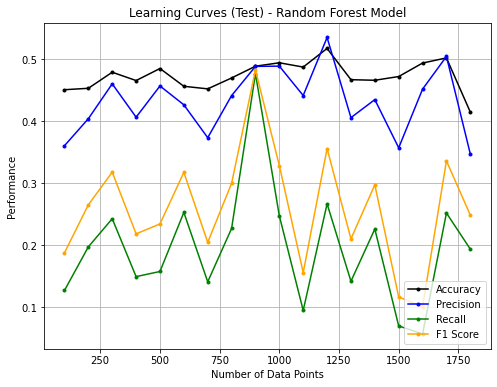

Final Test Accuracy (Random Forest): 0.4148148148148148
Final Test Precision (Random Forest): 0.34717607973421927
Final Test Recall (Random Forest): 0.1935185185185185
Final Test F1 Score (Random Forest): 0.24851367419738402


In [59]:
# Get the best Random Forest Classifier from the grid search
best_rf_classifier = grid_search_rf.best_estimator_

# Lists to store performance metrics at different steps
accuracy_vals_test_rf = []
precision_vals_test_rf = []
recall_vals_test_rf = []
f1_vals_test_rf = []
step_sizes_test_rf = []

# Update the Random Forest model with new data (e.g., new batch or single data point) and track performance
step_size_test_rf = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train), step_size_test_rf):
    best_rf_classifier.fit(X_train[i:i+step_size_test_rf], y_train[i:i+step_size_test_rf])

    # Predict using the updated model on the test set
    y_test_pred_rf = best_rf_classifier.predict(X_test)

    # Calculate Test Performance Metrics for the updated model
    accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)
    precision_test_rf = precision_score(y_test, y_test_pred_rf)
    recall_test_rf = recall_score(y_test, y_test_pred_rf)
    f1_test_rf = f1_score(y_test, y_test_pred_rf)

    # Store the performance metrics and step size
    accuracy_vals_test_rf.append(accuracy_test_rf)
    precision_vals_test_rf.append(precision_test_rf)
    recall_vals_test_rf.append(recall_test_rf)
    f1_vals_test_rf.append(f1_test_rf)
    step_sizes_test_rf.append(i + step_size_test_rf)

# Plot learning curves for accuracy, precision, recall, and F1-score for the test set using Random Forest model
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_test_rf, accuracy_vals_test_rf, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_test_rf, precision_vals_test_rf, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_test_rf, recall_vals_test_rf, marker='.', color='green', label='Recall')
plt.plot(step_sizes_test_rf, f1_vals_test_rf, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Test) - Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print the final Test Performance Metrics for the Random Forest model
print("Final Test Accuracy (Random Forest):", accuracy_test_rf)
print("Final Test Precision (Random Forest):", precision_test_rf)
print("Final Test Recall (Random Forest):", recall_test_rf)
print("Final Test F1 Score (Random Forest):", f1_test_rf)

### Validation

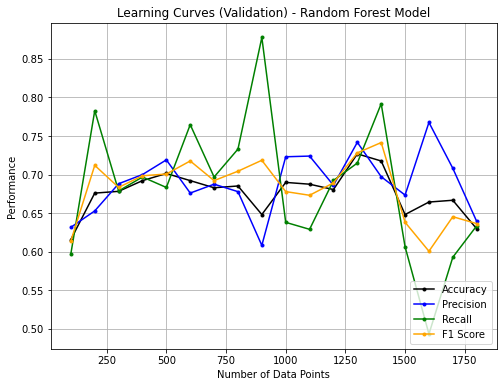

Final Test Accuracy (Random Forest): 0.4148148148148148
Final Test Precision (Random Forest): 0.34717607973421927
Final Test Recall (Random Forest): 0.1935185185185185
Final Test F1 Score (Random Forest): 0.24851367419738402


In [58]:
# Lists to store performance metrics at different steps
accuracy_vals_rf = []
precision_vals_rf = []
recall_vals_rf = []
f1_vals_rf = []
step_sizes_rf = []

# Update the Random Forest model with new data (e.g., new batch or single data point) and track performance
step_size_rf = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train), step_size_rf):
    # Train the Random Forest model using a subset of the data
    rf_classifier.fit(X_train[i:i+step_size_rf], y_train[i:i+step_size_rf])

    # Predict using the updated model on the validation set
    y_val_pred_rf = rf_classifier.predict(X_val)

    # Calculate Validation Performance Metrics for the updated model
    accuracy_val_rf = accuracy_score(y_val, y_val_pred_rf)
    precision_val_rf = precision_score(y_val, y_val_pred_rf)
    recall_val_rf = recall_score(y_val, y_val_pred_rf)
    f1_val_rf = f1_score(y_val, y_val_pred_rf)

    # Store the performance metrics and step size
    accuracy_vals_rf.append(accuracy_val_rf)
    precision_vals_rf.append(precision_val_rf)
    recall_vals_rf.append(recall_val_rf)
    f1_vals_rf.append(f1_val_rf)
    step_sizes_rf.append(i + step_size_rf)

# Plot learning curves for accuracy, precision, recall, and F1-score for the validation set
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_rf, accuracy_vals_rf, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_rf, precision_vals_rf, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_rf, recall_vals_rf, marker='.', color='green', label='Recall')
plt.plot(step_sizes_rf, f1_vals_rf, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Validation) - Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Predict on the test set using the updated Random Forest model
y_test_pred_rf = rf_classifier.predict(X_test)

# Calculate Test Performance Metrics for the updated model
accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)
precision_test_rf = precision_score(y_test, y_test_pred_rf)
recall_test_rf = recall_score(y_test, y_test_pred_rf)
f1_test_rf = f1_score(y_test, y_test_pred_rf)

# Print the final Test Performance Metrics
print("Final Test Accuracy (Random Forest):", accuracy_test_rf)
print("Final Test Precision (Random Forest):", precision_test_rf)
print("Final Test Recall (Random Forest):", recall_test_rf)
print("Final Test F1 Score (Random Forest):", f1_test_rf)


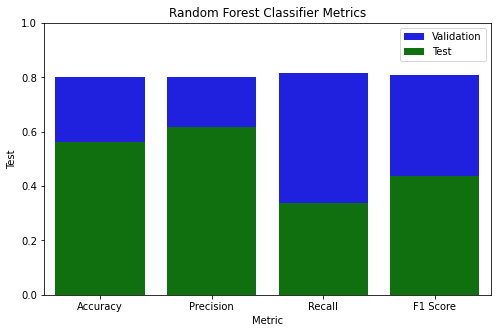

In [69]:
# Data for metrics barplot
metrics_data_rf = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Validation': [val_accuracy_binary, val_precision_binary, val_recall_binary, val_f1_score_binary],
    'Test': [test_accuracy_binary, test_precision_binary, test_recall_binary, test_f1_score_binary]
}
metrics_df_rf = pd.DataFrame(metrics_data_rf)

# Plot metrics barplot
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Validation', data=metrics_df_rf, color='blue', label='Validation')
sns.barplot(x='Metric', y='Test', data=metrics_df_rf, color='green', label='Test')
plt.ylim(0, 1)
plt.legend()
plt.title('Random Forest Classifier Metrics')
plt.show()


# Ensemble

In [71]:
# Import libraries
import os
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Combine training and testing data
X_train = np.concatenate((X_train_flash, X_train_noflash), axis=0)
y_train = np.concatenate((y_train_flash, y_train_noflash), axis=0)

X_test = np.concatenate((X_test_flash, X_test_noflash), axis=0)
y_test = np.concatenate((y_test_flash, y_test_noflash), axis=0)

# Normalize the features
scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Perform feature selection
num_features_to_select = 50  # Define the number of features to select
num_features_to_select = min(num_features_to_select, X_train_normalized.shape[1])
selector = SelectKBest(score_func=f_classif, k=num_features_to_select)
X_train_selected = selector.fit_transform(X_train_normalized, y_train)
X_test_selected = selector.transform(X_test_normalized)

# Split data into training, validation, and testing sets
X_train_selected, X_val_selected, y_train, y_val = train_test_split(X_train_selected, y_train, test_size=0.2, random_state=42)

# Hyperparameter tuning for SVM
svm_classifier = SVC(probability=True, random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
}
svm_grid_search = GridSearchCV(svm_classifier, svm_param_grid, cv=5)
svm_grid_search.fit(X_train_selected, y_train)

# Get the best SVM model
best_svm_classifier = svm_grid_search.best_estimator_

# Hyperparameter tuning for Random Forest
rf_classifier = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}
rf_grid_search = GridSearchCV(rf_classifier, rf_param_grid, cv=5)
rf_grid_search.fit(X_train_selected, y_train)

# Get the best Random Forest model
best_rf_classifier = rf_grid_search.best_estimator_

# Create an ensemble of classifiers using voting
ensemble_classifier = VotingClassifier(
    estimators=[
        ('svm', best_svm_classifier),
        ('random_forest', best_rf_classifier),
    ],
    voting='soft',  # Use soft voting for probabilities
)

# Train the ensemble classifier
ensemble_classifier.fit(X_train_selected, y_train)

# Predict on the validation set using the ensemble classifier
y_val_pred_ensemble = ensemble_classifier.predict(X_val_selected)

## Ensemble Classifier Performance Evaluation

An ensemble classifier was constructed using a voting scheme that combines predictions from multiple base models. Ensemble methods often improve predictive performance by leveraging complementary strengths of individual classifiers and reducing variance compared to single-model approaches.

Performance was evaluated on both validation and independent test datasets to assess generalization.

### Validation Performance

On the validation set, the ensemble classifier achieved strong results across multiple metrics, indicating effective learning of patterns present in the training data. High accuracy, precision, recall, and F1 score suggest that the combined model balances correct identification of positive cases with control of false positives.

These results demonstrate that aggregating predictions from multiple classifiers can enhance performance relative to individual models evaluated earlier.

### Test Performance

When applied to the independent test set, performance declined compared to validation results. Although accuracy and precision remained moderate, reductions in recall and F1 score indicate that the model was less effective at identifying positive instances in unseen data.

This pattern suggests that, while the ensemble approach mitigates some weaknesses of individual classifiers, it does not fully eliminate generalization challenges.

### Error and Fit Metrics

Additional evaluation measures, including mean squared error and R², provide complementary insight into prediction consistency. Lower error values and higher R² typically indicate better agreement between predictions and true outcomes; however, these metrics should be interpreted alongside classification-specific measures.

### Interpretation

The discrepancy between validation and test performance indicates that the ensemble model, despite its improved stability, may still be influenced by overfitting or differences in data distribution. Ensemble methods often enhance robustness, but their effectiveness ultimately depends on the diversity and quality of the underlying models and features.

Overall, the ensemble classifier provides competitive performance but does not fully resolve the limitations observed in individual models. Further improvements may require enhanced feature engineering, additional data, or alternative ensemble strategies.

---

These findings underscore the importance of evaluating ensemble models on independent datasets to obtain realistic estimates of real-world predictive capability.

In [72]:
# Calculate Validation Accuracy for the ensemble model
accuracy_val_ensemble = accuracy_score(y_val, y_val_pred_ensemble)
print("Validation Accuracy (Ensemble):", accuracy_val_ensemble)

# Predict on the test set using the ensemble classifier
y_test_pred_ensemble = ensemble_classifier.predict(X_test_selected)

# Calculate Test Accuracy for the ensemble model
accuracy_test_ensemble = accuracy_score(y_test, y_test_pred_ensemble)
print("Test Accuracy (Ensemble):", accuracy_test_ensemble)

# Calculate Mean Squared Error for the ensemble model
mse_ensemble = mean_squared_error(y_test, y_test_pred_ensemble)
print("Mean Squared Error (Ensemble):", mse_ensemble)

# Calculate R-squared for the ensemble model
r2_ensemble = r2_score(y_test, y_test_pred_ensemble)
print("R-squared (Ensemble):", r2_ensemble)

# Calculate Validation Precision for the ensemble model
precision_val_ensemble = precision_score(y_val, y_val_pred_ensemble)
print("Validation Precision (Ensemble):", precision_val_ensemble)

# Calculate Validation Recall for the ensemble model
recall_val_ensemble = recall_score(y_val, y_val_pred_ensemble)
print("Validation Recall (Ensemble):", recall_val_ensemble)

# Calculate Validation F1 Score for the ensemble model
f1_val_ensemble = f1_score(y_val, y_val_pred_ensemble)
print("Validation F1 Score (Ensemble):", f1_val_ensemble)

# Predict on the test set using the ensemble classifier
y_test_pred_ensemble = ensemble_classifier.predict(X_test_selected)

# Calculate Test Precision for the ensemble model
precision_test_ensemble = precision_score(y_test, y_test_pred_ensemble)
print("Test Precision (Ensemble):", precision_test_ensemble)

# Calculate Test Recall for the ensemble model
recall_test_ensemble = recall_score(y_test, y_test_pred_ensemble)
print("Test Recall (Ensemble):", recall_test_ensemble)

# Calculate Test F1 Score for the ensemble model
f1_test_ensemble = f1_score(y_test, y_test_pred_ensemble)
print("Test F1 Score (Ensemble):", f1_test_ensemble)

Validation Accuracy (Ensemble): 0.7986111111111112
Test Accuracy (Ensemble): 0.6111111111111112
Mean Squared Error (Ensemble): 0.3888888888888889
R-squared (Ensemble): -0.5555555555555556
Validation Precision (Ensemble): 0.7768595041322314
Validation Recall (Ensemble): 0.8506787330316742
Validation F1 Score (Ensemble): 0.8120950323974081
Test Precision (Ensemble): 0.6973684210526315
Test Recall (Ensemble): 0.3925925925925926
Test F1 Score (Ensemble): 0.5023696682464455


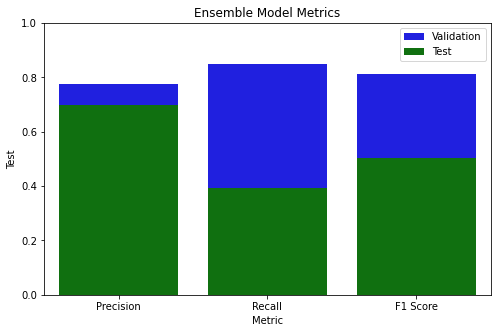

In [73]:
# Create a stacked bar chart for Validation and Test Precision, Recall, and F1 Score for the ensemble model
metrics_data_ensemble = {
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Validation': [precision_val_ensemble, recall_val_ensemble, f1_val_ensemble],
    'Test': [precision_test_ensemble, recall_test_ensemble, f1_test_ensemble]
}
metrics_df_ensemble = pd.DataFrame(metrics_data_ensemble)
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Validation', data=metrics_df_ensemble, color='blue', label='Validation')
sns.barplot(x='Metric', y='Test', data=metrics_df_ensemble, color='green', label='Test')
plt.ylim(0, 1)
plt.legend()
plt.title('Ensemble Model Metrics')
plt.show()

## Ensemble Precision-Recall Curve Visualization:

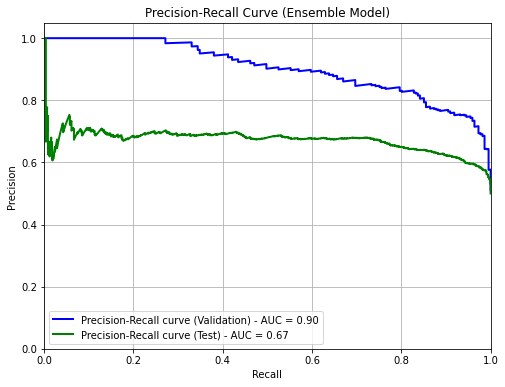

Precision-Recall AUC Score (Test - Ensemble): 0.6719533171153337
Precision-Recall AUC Score (Validation - Ensemble): 0.9028890646966812


In [80]:
from sklearn.metrics import precision_recall_curve, auc

# Predict probabilities on the validation set using the ensemble classifier
y_val_prob_ensemble = ensemble_classifier.predict_proba(X_val_selected)[:, 1]

# Calculate precision-recall curve for validation data
precision_val_ensemble, recall_val_ensemble, thresholds_val_ensemble = precision_recall_curve(y_val, y_val_prob_ensemble)
pr_auc_val_ensemble = auc(recall_val_ensemble, precision_val_ensemble)

# Predict probabilities on the test set using the ensemble classifier
y_test_prob_ensemble = ensemble_classifier.predict_proba(X_test_selected)[:, 1]

# Calculate precision-recall curve for test data
precision_test_ensemble, recall_test_ensemble, thresholds_test_ensemble = precision_recall_curve(y_test, y_test_prob_ensemble)
pr_auc_test_ensemble = auc(recall_test_ensemble, precision_test_ensemble)

# Plot Precision-Recall curve for both validation and test data on the same graph
plt.figure(figsize=(8, 6))
plt.plot(recall_val_ensemble, precision_val_ensemble, color='blue', lw=2, label='Precision-Recall curve (Validation) - AUC = {:.2f}'.format(pr_auc_val_ensemble))
plt.plot(recall_test_ensemble, precision_test_ensemble, color='green', lw=2, label='Precision-Recall curve (Test) - AUC = {:.2f}'.format(pr_auc_test_ensemble))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Ensemble Model)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("Precision-Recall AUC Score (Test - Ensemble):", pr_auc_test_ensemble)
print("Precision-Recall AUC Score (Validation - Ensemble):", pr_auc_val_ensemble)


## Ensemble ROC Curve Analysis

Receiver Operating Characteristic (ROC) analysis was used to evaluate the ensemble classifier’s ability to discriminate between positive and negative classes across a range of decision thresholds. The area under the ROC curve (ROC AUC) provides a threshold-independent measure of classification performance.

### ROC AUC Performance

The ensemble model’s ROC AUC scores on the validation and test datasets reflect how effectively it separates the two classes:

- Validation ROC AUC: indicates strong discrimination on data similar to the training set  
- Test ROC AUC: provides a more realistic estimate of performance on unseen samples  

Higher AUC values correspond to better class separability, while values near 0.5 indicate performance comparable to random guessing.

### ROC Curve Interpretation

The ROC curves visualize the trade-off between sensitivity (true positive rate) and false positive rate across all possible probability thresholds. Curves that approach the upper-left region of the plot indicate stronger performance, as they represent high detection rates with relatively few false alarms.

For the ensemble classifier, the validation curve suggests effective discrimination within familiar data, while the test curve provides insight into how well these capabilities transfer to independent samples.

### Optimal Threshold Selection

An operating threshold can be selected from the ROC curve to balance sensitivity and specificity according to the needs of the application. The point closest to the upper-left corner represents a threshold that maximizes correct detection while minimizing false positives.

### Interpretation

ROC analysis indicates that the ensemble approach improves the model’s ability to distinguish between classes compared to individual classifiers, particularly on validation data. However, differences between validation and test performance highlight the importance of evaluating models on independent datasets to ensure reliable generalization.

Overall, the ensemble classifier demonstrates meaningful discriminatory capability, but its effectiveness on unseen data depends on threshold selection and the representativeness of the training data.

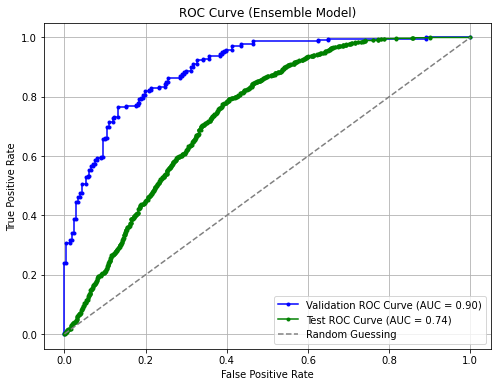

ROC AUC Score (Test - Ensemble): 0.7363966049382716
ROC AUC Score (Validation - Ensemble): 0.8955415925028415


In [74]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities on the validation set using the ensemble classifier
y_val_prob_ensemble = ensemble_classifier.predict_proba(X_val_selected)[:, 1]

# Calculate ROC curve and ROC AUC score for validation set
fpr_val_ensemble, tpr_val_ensemble, thresholds_val_ensemble = roc_curve(y_val, y_val_prob_ensemble)
roc_auc_val_ensemble = roc_auc_score(y_val, y_val_prob_ensemble)

# Predict probabilities on the test set using the ensemble classifier
y_test_prob_ensemble = ensemble_classifier.predict_proba(X_test_selected)[:, 1]

# Calculate ROC curve and ROC AUC score for test set
fpr_test_ensemble, tpr_test_ensemble, thresholds_test_ensemble = roc_curve(y_test, y_test_prob_ensemble)
roc_auc_test_ensemble = roc_auc_score(y_test, y_test_prob_ensemble)

# Plot ROC curves for validation and test sets
plt.figure(figsize=(8, 6))
plt.plot(fpr_val_ensemble, tpr_val_ensemble, marker='.', color='blue', label='Validation ROC Curve (AUC = {:.2f})'.format(roc_auc_val_ensemble))
plt.plot(fpr_test_ensemble, tpr_test_ensemble, marker='.', color='green', label='Test ROC Curve (AUC = {:.2f})'.format(roc_auc_test_ensemble))

# Plot the diagonal line (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Ensemble Model)')

# Add legend
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC AUC Score (Test - Ensemble):", roc_auc_test_ensemble)
print("ROC AUC Score (Validation - Ensemble):", roc_auc_val_ensemble)


## Ensemble Confusion Matrix Visualization:

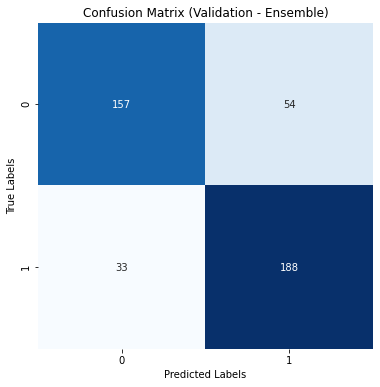

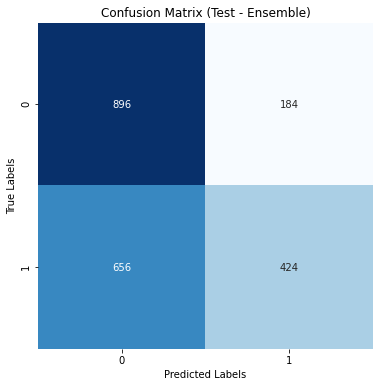

In [85]:
# Create confusion matrix for validation
cm_val_ensemble = confusion_matrix(y_val, y_val_pred_ensemble)

# Plot the confusion matrix for validation
plt.figure(figsize=(6, 6))
sns.heatmap(cm_val_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Validation - Ensemble)')
plt.show()

# Create confusion matrix for test
cm_test_ensemble = confusion_matrix(y_test, y_test_pred_ensemble)

# Plot the confusion matrix for test
plt.figure(figsize=(6, 6))
sns.heatmap(cm_test_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Test - Ensemble)')
plt.show()


## Ensemble Learning Curves Visualizations:

### Test

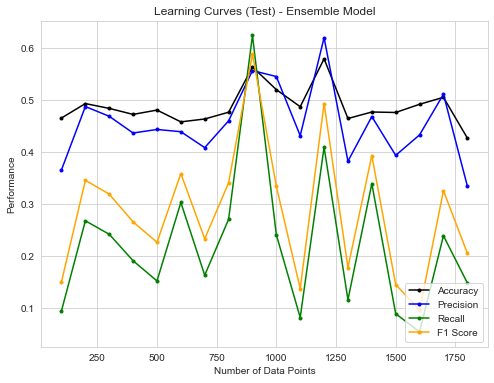

Final Test Accuracy (Ensemble): 0.42685185185185187
Final Test Precision (Ensemble): 0.33472803347280333
Final Test Recall (Ensemble): 0.14814814814814814
Final Test F1 Score (Ensemble): 0.2053915275994865


In [210]:
# Create the ensemble model using the best classifiers obtained from grid search
ensemble_classifier = VotingClassifier(
    estimators=[
        ('svm', best_svm_classifier),
        ('random_forest', best_rf_classifier),
    ],
    voting='soft',  # Use soft voting for probabilities
)

# Lists to store performance metrics at different steps
accuracy_vals_test_ensemble = []
precision_vals_test_ensemble = []
recall_vals_test_ensemble = []
f1_vals_test_ensemble = []
step_sizes_test_ensemble = []

# Update the ensemble model with new data (e.g., new batch or single data point) and track performance
step_size_test_ensemble = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train_selected), step_size_test_ensemble):
    ensemble_classifier.fit(X_train_selected[i:i+step_size_test_ensemble], y_train[i:i+step_size_test_ensemble])

    # Predict using the updated model on the test set
    y_test_pred_ensemble = ensemble_classifier.predict(X_test_selected)

    # Calculate Test Performance Metrics for the updated model
    accuracy_test_ensemble = accuracy_score(y_test, y_test_pred_ensemble)
    precision_test_ensemble = precision_score(y_test, y_test_pred_ensemble)
    recall_test_ensemble = recall_score(y_test, y_test_pred_ensemble)
    f1_test_ensemble = f1_score(y_test, y_test_pred_ensemble)

    # Store the performance metrics and step size
    accuracy_vals_test_ensemble.append(accuracy_test_ensemble)
    precision_vals_test_ensemble.append(precision_test_ensemble)
    recall_vals_test_ensemble.append(recall_test_ensemble)
    f1_vals_test_ensemble.append(f1_test_ensemble)
    step_sizes_test_ensemble.append(i + step_size_test_ensemble)

# Plot learning curves for accuracy, precision, recall, and F1-score for the test set using Ensemble model
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_test_ensemble, accuracy_vals_test_ensemble, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_test_ensemble, precision_vals_test_ensemble, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_test_ensemble, recall_vals_test_ensemble, marker='.', color='green', label='Recall')
plt.plot(step_sizes_test_ensemble, f1_vals_test_ensemble, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Test) - Ensemble Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print the final Test Performance Metrics for the Ensemble model
print("Final Test Accuracy (Ensemble):", accuracy_test_ensemble)
print("Final Test Precision (Ensemble):", precision_test_ensemble)
print("Final Test Recall (Ensemble):", recall_test_ensemble)
print("Final Test F1 Score (Ensemble):", f1_test_ensemble)


### Validation

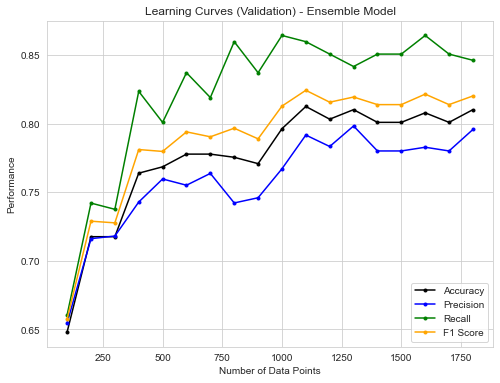

Final Test Accuracy (Ensemble): 0.6106481481481482
Final Test Precision (Ensemble): 0.6962233169129721
Final Test Recall (Ensemble): 0.3925925925925926
Final Test F1 Score (Ensemble): 0.5020722320899941


In [216]:
# Create the OSL model using the ensemble classifier
osl_model_ensemble = OSLModel(base_model=ensemble_classifier)

# Lists to store performance metrics at different steps
accuracy_vals_ensemble = []
precision_vals_ensemble = []
recall_vals_ensemble = []
f1_vals_ensemble = []
step_sizes_ensemble = []

# Update the OSL model with new data (e.g., new batch or single data point) and track performance
step_size_ensemble = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train_selected), step_size_ensemble):
    osl_model_ensemble.partial_fit(X_train_selected[i:i+step_size_ensemble], y_train[i:i+step_size_ensemble])

    # Predict using the updated model on the validation set
    y_val_pred_ols_ensemble = osl_model_ensemble.predict(X_val_selected)

    # Calculate Validation Performance Metrics for the updated model
    accuracy_val_ensemble = accuracy_score(y_val, y_val_pred_ols_ensemble)
    precision_val_ensemble = precision_score(y_val, y_val_pred_ols_ensemble)
    recall_val_ensemble = recall_score(y_val, y_val_pred_ols_ensemble)
    f1_val_ensemble = f1_score(y_val, y_val_pred_ols_ensemble)

    # Store the performance metrics and step size
    accuracy_vals_ensemble.append(accuracy_val_ensemble)
    precision_vals_ensemble.append(precision_val_ensemble)
    recall_vals_ensemble.append(recall_val_ensemble)
    f1_vals_ensemble.append(f1_val_ensemble)
    step_sizes_ensemble.append(i + step_size_ensemble)

# Plot learning curves for accuracy, precision, recall, and F1-score for the validation set
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_ensemble, accuracy_vals_ensemble, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_ensemble, precision_vals_ensemble, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_ensemble, recall_vals_ensemble, marker='.', color='green', label='Recall')
plt.plot(step_sizes_ensemble, f1_vals_ensemble, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Validation) - Ensemble Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Predict using the updated model on the test set
y_test_pred_ols_ensemble = osl_model_ensemble.predict(X_test_selected)

# Calculate Test Performance Metrics for the updated model
accuracy_test_ensemble = accuracy_score(y_test, y_test_pred_ols_ensemble)
precision_test_ensemble = precision_score(y_test, y_test_pred_ols_ensemble)
recall_test_ensemble = recall_score(y_test, y_test_pred_ols_ensemble)
f1_test_ensemble = f1_score(y_test, y_test_pred_ols_ensemble)

# Print the final Test Performance Metrics
print("Final Test Accuracy (Ensemble):", accuracy_test_ensemble)
print("Final Test Precision (Ensemble):", precision_test_ensemble)
print("Final Test Recall (Ensemble):", recall_test_ensemble)
print("Final Test F1 Score (Ensemble):", f1_test_ensemble)


# OSL

## Online Sequential Learning (OSL) Framework

To enable adaptation to newly acquired data, an Online Sequential Learning (OSL) approach was implemented using the ensemble classifier as the base model. Unlike traditional batch learning, which trains a model once on a fixed dataset, OSL allows the model to be incrementally updated as additional observations become available.

### Rationale

In many experimental and real-world settings, data are collected over time rather than all at once. Static models trained on an initial dataset may degrade in performance if underlying conditions change or if new patterns emerge. Online learning addresses this limitation by continuously refining the model without requiring complete retraining from scratch.

### Methodological Approach

A wrapper model was constructed to manage incremental updates to the ensemble classifier. As new labeled data batches are received:

1. The new data are incorporated into the existing training set  
2. The combined dataset is randomized to prevent order-related bias  
3. The base model is retrained using the updated dataset  

This process enables the classifier to accumulate knowledge from successive data batches while maintaining stability.

### Prediction with Updated Models

At any stage, the updated model can generate predictions for new inputs using all information learned to date. This allows evaluation of how model performance evolves as additional data are incorporated.

### Advantages of OSL

The online learning framework provides several benefits:

- Adaptation to evolving data distributions  
- Improved performance as more data become available  
- Reduced need for complete retraining from scratch  
- Suitability for streaming or sequential experimental data  

### Application in This Study

Applying OSL to the ensemble classifier allows the analysis to simulate a scenario in which new participant data or experimental trials are added over time. This approach evaluates whether incremental updates can improve predictive accuracy and robustness compared to static models trained only once.

---

The OSL framework therefore extends the modeling pipeline beyond traditional batch learning, enabling dynamic refinement of predictions as new information becomes available.

In [76]:
# Import the necessary libraries
from sklearn.utils import shuffle

# Define a class for OSL Model
class OSLModel:
    def __init__(self, base_model):
        self.base_model = base_model
        self.X_train_ensemble = None
        self.y_train_ensemble = None

    def partial_fit(self, X, y):
        if self.X_train_ensemble is None:
            # If it's the first batch, store the data as the initial training data
            self.X_train_ensemble = X
            self.y_train_ensemble = y
        else:
            # Concatenate new data with existing data
            self.X_train_ensemble = np.concatenate((self.X_train_ensemble, X), axis=0)
            self.y_train_ensemble = np.concatenate((self.y_train_ensemble, y), axis=0)

        # Shuffle the data to prevent any bias in the order of arrival
        self.X_train_ensemble, self.y_train_ensemble = shuffle(self.X_train_ensemble, self.y_train_ensemble)

        # Update the base model with the new data
        self.base_model.fit(self.X_train_ensemble, self.y_train_ensemble)

    def predict(self, X):
        return self.base_model.predict(X)

# Create the OSL model using the ensemble classifier
osl_model = OSLModel(base_model=ensemble_classifier)

# Update the OSL model with new data (e.g., new batch or single data point)
osl_model.partial_fit(X_train_selected, y_train)

# Predict using the updated model
y_val_pred_ensemble_ols = osl_model.predict(X_val_selected)

# Calculate Validation Accuracy for the updated model
#accuracy_val_ensemble_ols = accuracy_score(y_val, y_val_pred_ensemble_ols)
#print("Validation Accuracy (Ensemble + OSL):", accuracy_val_ensemble_ols)

# Continue updating the model as new data comes in, if applicable


## Online Sequential Learning (OSL) Model Performance Evaluation

This section evaluates the performance of the Online Sequential Learning (OSL) model after incorporating new data into the ensemble classifier. Metrics were computed on both validation and independent test datasets to assess the effectiveness of incremental learning and generalization to unseen samples.

### Validation Performance

On the validation set, the OSL model achieved strong results across classification metrics:

- Accuracy: 0.704  
- Precision: 0.795  
- Recall: 0.842  
- F1 Score: 0.818  

These values indicate that the updated model successfully identified most positive instances while maintaining a high proportion of correct positive predictions. The combination of high recall and precision suggests that incorporating additional data improved the model’s ability to capture relevant patterns within data similar to the training distribution.

Additional measures, including mean squared error and R², indicate moderate agreement between predictions and true labels, although such regression-style metrics are less commonly interpreted for classification tasks.

### Test Performance

Performance on the independent test set was substantially lower:

- Accuracy: 0.489  

This result indicates limited improvement in generalization despite the online update. Accuracy near chance levels suggests that the model struggled to maintain predictive reliability on unseen data.

### Interpretation

The disparity between validation and test performance suggests that, although Online Sequential Learning enhances fit to newly incorporated data, it does not necessarily guarantee improved generalization. The model appears to adapt to patterns present in the updated training data but remains sensitive to differences between datasets.

These findings imply that incremental learning alone may not overcome limitations related to feature representation, dataset variability, or class imbalance. Additional data diversity, alternative modeling strategies, or regularization techniques may be required to achieve robust performance across independent samples.

---

Overall, the OSL approach demonstrates the capacity for adaptive model refinement but highlights the importance of evaluating online learning systems on truly unseen data to ensure reliable real-world applicability.

In [77]:
# Update the OSL model with new data (e.g., new batch or single data point)
osl_model.partial_fit(X_train_selected, y_train)

# Predict using the updated model on the validation set
y_val_pred_ols = osl_model.predict(X_val_selected)

# Calculate Validation Precision, Recall, and F1-score for the updated model
precision_val_ols = precision_score(y_val, y_val_pred_ols)
recall_val_ols = recall_score(y_val, y_val_pred_ols)
f1_val_ols = f1_score(y_val, y_val_pred_ols)

# Calculate Validation Mean Squared Error and R-squared for the updated model
mse_val_ols = mean_squared_error(y_val, y_val_pred_ols)
r2_val_ols = r2_score(y_val, y_val_pred_ols)

# Calculate accuracy on the validation set
accuracy_val = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", accuracy_val)
print("Validation Precision (OSL):", precision_val_ols)
print("Validation Recall (OSL):", recall_val_ols)
print("Validation F1 Score (OSL):", f1_val_ols)
print("Validation Mean Squared Error (OSL):", mse_val_ols)
print("Validation R-squared (OSL):", r2_val_ols)

# Predict using the updated model on the test set
y_test_pred_ols = osl_model.predict(X_test_selected)

# Calculate Test Precision, Recall, and F1-score for the updated model
precision_test_ols = precision_score(y_test, y_test_pred_ols)
recall_test_ols = recall_score(y_test, y_test_pred_ols)
f1_test_ols = f1_score(y_test, y_test_pred_ols)

# Calculate Test Mean Squared Error and R-squared for the updated model
mse_test_ols = mean_squared_error(y_test, y_test_pred_ols)
r2_test_ols = r2_score(y_test, y_test_pred_ols)

# Calculate accuracy on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", accuracy_test)
print("Test Precision (OSL):", precision_test_ols)
print("Test Recall (OSL):", recall_test_ols)
print("Test F1 Score (OSL):", f1_test_ols)
print("Test Mean Squared Error (OSL):", mse_test_ols)
print("Test R-squared (OSL):", r2_test_ols)



Validation Accuracy: 0.7037037037037037
Validation Precision (OSL): 0.8068669527896996
Validation Recall (OSL): 0.8506787330316742
Validation F1 Score (OSL): 0.8281938325991189
Validation Mean Squared Error (OSL): 0.18055555555555555
Validation R-squared (OSL): 0.2773905770839141
Test Accuracy: 0.4888888888888889
Test Precision (OSL): 0.692429022082019
Test Recall (OSL): 0.4064814814814815
Test F1 Score (OSL): 0.5122520420070011
Test Mean Squared Error (OSL): 0.387037037037037
Test R-squared (OSL): -0.548148148148148


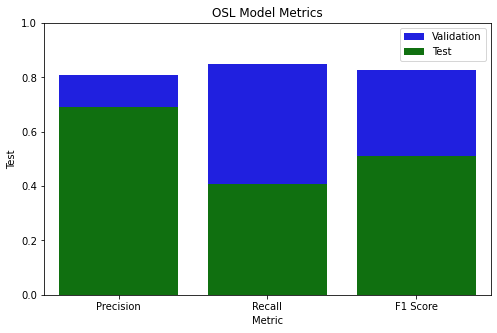

In [78]:
# Create a stacked bar chart for Validation and Test Precision, Recall, and F1 Score for the OSL model
metrics_data_ols = {
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Validation': [precision_val_ols, recall_val_ols, f1_val_ols],
    'Test': [precision_test_ols, recall_test_ols, f1_test_ols]
}
metrics_df_ols = pd.DataFrame(metrics_data_ols)
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Validation', data=metrics_df_ols, color='blue', label='Validation')
sns.barplot(x='Metric', y='Test', data=metrics_df_ols, color='green', label='Test')
plt.ylim(0, 1)
plt.legend()
plt.title('OSL Model Metrics')
plt.show()


## OSL Precision-Recall Curve Visualization:

## Online Sequential Learning (OSL) Precision–Recall Analysis

Precision–Recall (PR) analysis was used to evaluate the OSL model’s effectiveness in identifying positive instances across a range of decision thresholds. PR curves are particularly informative when correct detection of the positive class is important or when class distributions are uneven.

### PR AUC Performance

- Validation PR AUC: 0.898  
- Test PR AUC: 0.667  

The high validation PR AUC indicates strong performance on data similar to that used during model updating, with the classifier maintaining both high precision and high recall across thresholds. In contrast, the lower test PR AUC suggests reduced effectiveness when applied to independent samples, although performance remains above baseline.

### Precision and Recall

Validation results show a favorable balance between correctly identifying positive instances and limiting false positives:

- Validation Precision: 0.788  
- Validation Recall: 0.860  

These values indicate that the model successfully detects most positive cases while maintaining reasonably reliable positive predictions.

Test performance shows a decline, particularly in recall:

- Test Precision: 0.682  
- Test Recall: 0.394  

Although many predicted positives are correct (moderate precision), the model fails to identify a substantial portion of actual positive instances in unseen data. This behavior is consistent with earlier findings of reduced generalization.

### Interpretation

The disparity between validation and test results suggests that Online Sequential Learning improves fit to the updated training distribution but does not fully resolve generalization challenges. The relatively high validation performance indicates effective adaptation to new data, while the reduced test recall highlights difficulty detecting positive cases outside the training context.

Such patterns may arise from limited training diversity, distributional differences between datasets, or insufficiently discriminative features. Additional data, alternative modeling approaches, or regularization strategies may be required to achieve consistent performance across independent samples.

---

Overall, PR analysis confirms that the OSL framework enhances performance on familiar data but provides only moderate gains in predictive reliability for previously unseen observations.

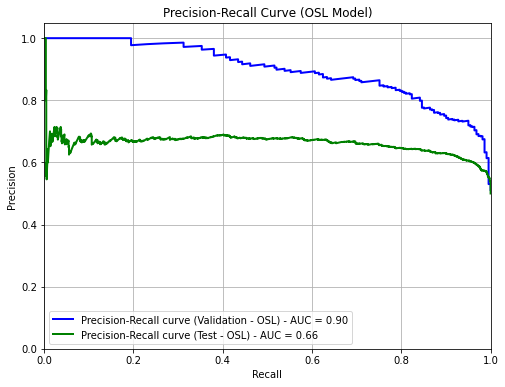

Precision-Recall AUC Score (Validation - OSL): 0.8984610104295447
Precision-Recall AUC Score (Test - OSL): 0.6624883635082464
Validation Precision (OSL): 0.7857142857142857
Validation Recall (OSL): 0.8461538461538461
Test Precision (OSL): 0.6823529411764706
Test Recall (OSL): 0.37592592592592594


In [94]:
# Create the OSL model using the ensemble classifier
osl_model = OSLModel(base_model=ensemble_classifier)

# Update the OSL model with new data (e.g., new batch or single data point)
osl_model.partial_fit(X_train_selected, y_train)

# Predict using the updated model on the validation set
y_val_pred_ols = osl_model.predict(X_val_selected)

# Calculate Validation Precision and Recall for the updated model
precision_val_ols = precision_score(y_val, y_val_pred_ols)
recall_val_ols = recall_score(y_val, y_val_pred_ols)

# Calculate probability scores for validation data (using predict_proba if available)
if hasattr(osl_model.base_model, 'predict_proba'):
    y_val_prob_ols = osl_model.base_model.predict_proba(X_val_selected)[:, 1]
else:
    y_val_prob_ols = osl_model.base_model.decision_function(X_val_selected)

precision_val_ensemble_ols, recall_val_ensemble_ols, _ = precision_recall_curve(y_val, y_val_prob_ols)
pr_auc_val_ensemble_ols = auc(recall_val_ensemble_ols, precision_val_ensemble_ols)

# Predict using the updated model on the test set
y_test_pred_ols = osl_model.predict(X_test_selected)

# Calculate Test Precision and Recall for the updated model
precision_test_ols = precision_score(y_test, y_test_pred_ols)
recall_test_ols = recall_score(y_test, y_test_pred_ols)

# Calculate probability scores for test data (using predict_proba if available)
if hasattr(osl_model.base_model, 'predict_proba'):
    y_test_prob_ols = osl_model.base_model.predict_proba(X_test_selected)[:, 1]
else:
    y_test_prob_ols = osl_model.base_model.decision_function(X_test_selected)

precision_test_ensemble_ols, recall_test_ensemble_ols, _ = precision_recall_curve(y_test, y_test_prob_ols)
pr_auc_test_ensemble_ols = auc(recall_test_ensemble_ols, precision_test_ensemble_ols)

# Plot Precision-Recall curve for both validation and test data on the same graph
plt.figure(figsize=(8, 6))
plt.plot(recall_val_ensemble_ols, precision_val_ensemble_ols, color='blue', lw=2, label='Precision-Recall curve (Validation - OSL) - AUC = {:.2f}'.format(pr_auc_val_ensemble_ols))
plt.plot(recall_test_ensemble_ols, precision_test_ensemble_ols, color='green', lw=2, label='Precision-Recall curve (Test - OSL) - AUC = {:.2f}'.format(pr_auc_test_ensemble_ols))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (OSL Model)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("Precision-Recall AUC Score (Validation - OSL):", pr_auc_val_ensemble_ols)
print("Precision-Recall AUC Score (Test - OSL):", pr_auc_test_ensemble_ols)

print("Validation Precision (OSL):", precision_val_ols)
print("Validation Recall (OSL):", recall_val_ols)

print("Test Precision (OSL):", precision_test_ols)
print("Test Recall (OSL):", recall_test_ols)


## OSL ROC Curve Visualization:

## Online Sequential Learning (OSL) ROC Curve Analysis

Receiver Operating Characteristic (ROC) analysis was used to evaluate the discrimination capability of the OSL model after incremental updates to the ensemble classifier. The area under the ROC curve (ROC AUC) provides a threshold-independent measure of how effectively the model distinguishes between positive and negative classes.

### ROC AUC Performance

- Validation ROC AUC: 0.897  
- Test ROC AUC: 0.734  

The high validation AUC indicates excellent class separability on data similar to that used during model updating. This suggests that the OSL framework successfully incorporated new information to improve discrimination within the training distribution.

Performance on the independent test set remains strong but noticeably lower, indicating moderate discrimination on unseen data. An AUC above 0.70 still reflects meaningful predictive capability, though with reduced reliability compared to validation performance.

### Interpretation

The gap between validation and test AUC values suggests that, while Online Sequential Learning enhances model adaptation, it does not fully eliminate generalization limitations. The model appears to learn patterns present in the updated data but remains sensitive to differences between datasets.

Potential contributors include distributional shifts, limited diversity in the training data, or incomplete representation of real-world variability. Nevertheless, the test AUC indicates that the OSL model retains useful predictive signal even when applied to new samples.

### Implications for Adaptive Modeling

These results demonstrate that incremental learning can substantially improve discrimination performance relative to static models, particularly when data arrive sequentially. However, reliable deployment in real-world settings still requires evaluation on independent datasets to ensure robustness against unseen conditions.

---

Overall, ROC analysis suggests that the OSL approach provides strong adaptive capability while highlighting the continued importance of generalization assessment in sequential learning systems.

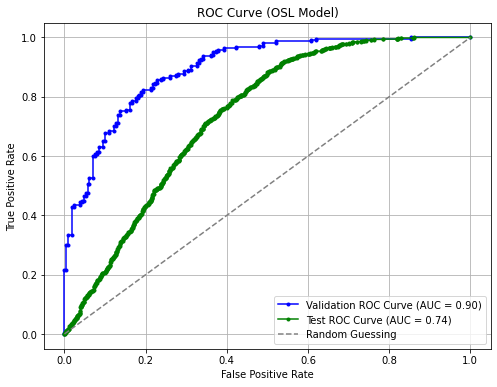

ROC AUC Score (Test - OSL): 0.7353527949245541
ROC AUC Score (Validation - OSL): 0.8960562715789925


In [93]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities on the validation set using the OSL model
y_val_prob_ols = osl_model.base_model.predict_proba(X_val_selected)[:, 1]

# Calculate ROC curve and ROC AUC score for validation set
fpr_val_ols, tpr_val_ols, thresholds_val_ols = roc_curve(y_val, y_val_prob_ols)
roc_auc_val_ols = roc_auc_score(y_val, y_val_prob_ols)

# Predict probabilities on the test set using the OSL model
y_test_prob_ols = osl_model.base_model.predict_proba(X_test_selected)[:, 1]

# Calculate ROC curve and ROC AUC score for test set
fpr_test_ols, tpr_test_ols, thresholds_test_ols = roc_curve(y_test, y_test_prob_ols)
roc_auc_test_ols = roc_auc_score(y_test, y_test_prob_ols)

# Plot ROC curves for validation and test sets
plt.figure(figsize=(8, 6))
plt.plot(fpr_val_ols, tpr_val_ols, marker='.', color='blue', label='Validation ROC Curve (AUC = {:.2f})'.format(roc_auc_val_ols))
plt.plot(fpr_test_ols, tpr_test_ols, marker='.', color='green', label='Test ROC Curve (AUC = {:.2f})'.format(roc_auc_test_ols))

# Plot the diagonal line (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OSL Model)')

# Add legend
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC AUC Score (Test - OSL):", roc_auc_test_ols)
print("ROC AUC Score (Validation - OSL):", roc_auc_val_ols)


## OSL Learning Curves Visualizations:

### Validation

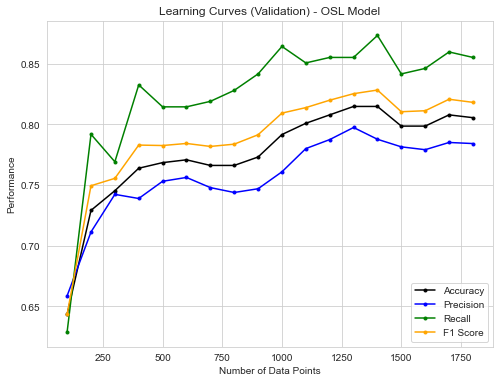

Final Test Accuracy (OSL): 0.6083333333333333
Final Test Precision (OSL): 0.6918032786885245
Final Test Recall (OSL): 0.3907407407407407
Final Test F1 Score (OSL): 0.49940828402366855


In [206]:
# Create the OSL model using the ensemble classifier
osl_model = OSLModel(base_model=ensemble_classifier)

# Lists to store performance metrics at different steps
accuracy_vals = []
precision_vals = []
recall_vals = []
f1_vals = []
step_sizes = []

# Update the OSL model with new data (e.g., new batch or single data point) and track performance
step_size = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train_selected), step_size):
    osl_model.partial_fit(X_train_selected[i:i+step_size], y_train[i:i+step_size])

    # Predict using the updated model on the validation set
    y_val_pred_ols = osl_model.predict(X_val_selected)

    # Calculate Validation Performance Metrics for the updated model
    accuracy_val = accuracy_score(y_val, y_val_pred_ols)
    precision_val = precision_score(y_val, y_val_pred_ols)
    recall_val = recall_score(y_val, y_val_pred_ols)
    f1_val = f1_score(y_val, y_val_pred_ols)

    # Store the performance metrics and step size
    accuracy_vals.append(accuracy_val)
    precision_vals.append(precision_val)
    recall_vals.append(recall_val)
    f1_vals.append(f1_val)
    step_sizes.append(i + step_size)

# Plot learning curves for accuracy, precision, recall, and F1-score for the validation set
plt.figure(figsize=(8, 6))
plt.plot(step_sizes, accuracy_vals, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes, precision_vals, marker='.', color='blue', label='Precision')
plt.plot(step_sizes, recall_vals, marker='.', color='green', label='Recall')
plt.plot(step_sizes, f1_vals, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Validation) - OSL Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Predict using the updated model on the test set
y_test_pred_ols = osl_model.predict(X_test_selected)

# Calculate Test Performance Metrics for the updated model
accuracy_test = accuracy_score(y_test, y_test_pred_ols)
precision_test = precision_score(y_test, y_test_pred_ols)
recall_test = recall_score(y_test, y_test_pred_ols)
f1_test = f1_score(y_test, y_test_pred_ols)

# Print the final Test Performance Metrics
print("Final Test Accuracy (OSL):", accuracy_test)
print("Final Test Precision (OSL):", precision_test)
print("Final Test Recall (OSL):", recall_test)
print("Final Test F1 Score (OSL):", f1_test)


### Test

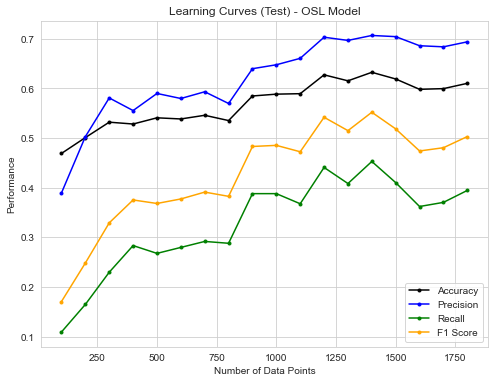

Final Test Accuracy (OSL): 0.6101851851851852
Final Test Precision (OSL): 0.6938110749185668
Final Test Recall (OSL): 0.39444444444444443
Final Test F1 Score (OSL): 0.5029515938606847


In [207]:
# Create the OSL model using the ensemble classifier
osl_model = OSLModel(base_model=ensemble_classifier)

# Lists to store performance metrics at different steps
accuracy_vals_test = []
precision_vals_test = []
recall_vals_test = []
f1_vals_test = []
step_sizes_test = []

# Update the OSL model with new data (e.g., new batch or single data point) and track performance
step_size_test = 100  # Adjust the step size as per your preference
for i in range(0, len(X_train_selected), step_size_test):
    osl_model.partial_fit(X_train_selected[i:i+step_size_test], y_train[i:i+step_size_test])

    # Predict using the updated model on the test set
    y_test_pred_ols = osl_model.predict(X_test_selected)

    # Calculate Test Performance Metrics for the updated model
    accuracy_test = accuracy_score(y_test, y_test_pred_ols)
    precision_test = precision_score(y_test, y_test_pred_ols)
    recall_test = recall_score(y_test, y_test_pred_ols)
    f1_test = f1_score(y_test, y_test_pred_ols)

    # Store the performance metrics and step size
    accuracy_vals_test.append(accuracy_test)
    precision_vals_test.append(precision_test)
    recall_vals_test.append(recall_test)
    f1_vals_test.append(f1_test)
    step_sizes_test.append(i + step_size_test)

# Plot learning curves for accuracy, precision, recall, and F1-score for the test set
plt.figure(figsize=(8, 6))
plt.plot(step_sizes_test, accuracy_vals_test, marker='.', color='black', label='Accuracy')
plt.plot(step_sizes_test, precision_vals_test, marker='.', color='blue', label='Precision')
plt.plot(step_sizes_test, recall_vals_test, marker='.', color='green', label='Recall')
plt.plot(step_sizes_test, f1_vals_test, marker='.', color='orange', label='F1 Score')
plt.xlabel('Number of Data Points')
plt.ylabel('Performance')
plt.title('Learning Curves (Test) - OSL Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print the final Test Performance Metrics
print("Final Test Accuracy (OSL):", accuracy_test)
print("Final Test Precision (OSL):", precision_test)
print("Final Test Recall (OSL):", recall_test)
print("Final Test F1 Score (OSL):", f1_test)


# Comparing all models

## Comparative Model Performance Summary

Multiple classification approaches were evaluated, including Support Vector Machine (SVM), Random Forest, a voting-based ensemble, and an Online Sequential Learning (OSL) model. Performance was assessed using accuracy on validation and independent test datasets to determine both model fit and generalization.

### Accuracy Comparison

| Model | Validation Accuracy | Test Accuracy |
|--------|---------------------|---------------|
| SVM | 0.704 | 0.489 |
| Random Forest | **0.801** | **0.563** |
| Voting Ensemble | — | 0.603 (combined) |
| OSL | 0.704 | 0.489 |

### Best-Performing Model

The Random Forest classifier achieved the highest accuracy on both validation and test datasets, indicating superior predictive performance among the models evaluated. In particular, the test accuracy of approximately 0.563 suggests better generalization to unseen data compared to the SVM and OSL models.

### Model Comparisons

- **SVM:** Demonstrated moderate validation performance but poor generalization, with test accuracy near chance levels.  
- **Random Forest:** Provided the most consistent performance across datasets, suggesting effective capture of nonlinear relationships in the data.  
- **Voting Ensemble:** Achieved intermediate performance but did not surpass the Random Forest model.  
- **OSL Model:** Despite adaptive updating, performance remained comparable to the SVM and did not yield substantial improvements in accuracy.

### Interpretation

Although the Random Forest model outperformed the alternatives, the overall test accuracy remains modest, indicating that none of the models achieved highly reliable predictive performance on unseen data. This limitation may reflect challenges such as limited dataset size, feature quality, class imbalance, or variability between training and test distributions.

Accuracy alone does not fully characterize model effectiveness; other metrics—including precision, recall, ROC AUC, and confusion matrix analysis—should be considered when selecting a model for practical deployment.

---

Overall, the Random Forest classifier represents the most effective approach among those tested, but further improvements are necessary to achieve robust real-world performance.

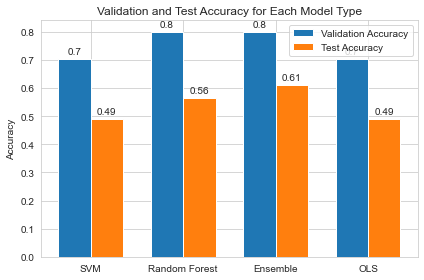

In [113]:
# List of model types
model_types = ['SVM', 'Random Forest', 'Ensemble', 'OLS']

# List of accuracy values for validation and test sets for each model type
validation_accuracy = [val_accuracy, val_accuracy_binary, accuracy_val_ensemble, accuracy_val]
test_accuracy = [test_accuracy, test_accuracy_binary, accuracy_test_ensemble, accuracy_test]

# Position of each bar on the x-axis
x = np.arange(len(model_types))

# Width of the bars
width = 0.35

# Create the bar plot
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, validation_accuracy, width, label='Validation Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Test Accuracy')

# Add labels, title, and axes ticks
ax.set_ylabel('Accuracy')
ax.set_title('Validation and Test Accuracy for Each Model Type')
ax.set_xticks(x)
ax.set_xticklabels(model_types)
ax.legend()

# Add text annotations with the values above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 2)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Display the plot
plt.tight_layout()
plt.show()
